# Bayesian Optimization — Function 8 (8D, Improved)

This notebook runs one step of Bayesian Optimization on an **8-dimensional** black-box function.

### Improvements over the original F8 script

| Area | Original | Improved |
|---|---|---|
| **Seed** | None | `np.random.default_rng(42)` |
| **Data path** | Hardcoded Windows path | `pathlib.Path(".")` — portable |
| **y transform** | None | None needed (well-scaled: 5.59 to 9.60) |
| **Kernel** | RBF | Matern nu=2.5 |
| **WhiteKernel bound** | `(1e-10, 1e-3)` | `(1e-10, 1e-1)` — less restrictive |
| **xi** | Fixed at 0.1 | Adaptive (starts at 0.1, decays) |
| **Sampling** | 150k pure random | 150k Sobol quasi-random |
| **L-BFGS-B starts** | 5 | 15 |
| **Acquisition** | EI only | EI or UCB (switchable) |
| **Structure** | One-shot script | Full BO loop with history tracking |
| **Visualization** | None | Top-8 most informative slice pairs + length scales + convergence plot |

## 1. Imports & Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import norm, qmc
from scipy.optimize import minimize

# ── SVM: Classify high vs low regions ────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# ── Neural Network: MC-Dropout surrogate ─────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Reproducibility
SEED = 42
rng  = np.random.default_rng(SEED)
torch.manual_seed(SEED)

## 2. Data Loading

F8 is **8-dimensional** with output values ranging from approximately **5.59 to 9.60** — a well-scaled range of about 4 units. No log-transform is needed; the GP fits the raw values without calibration issues.

With 40 initial observations spread across 8 dimensions, the average spacing between points is much larger than in lower-dimensional cases. This means:
- The GP will have **higher predictive uncertainty** across most of the space
- Boundary hits in the suggested point (e.g. `x4=0.0`, `x8=0.0` in the original) are less alarming than in 2D-4D — they often reflect genuine uncertainty rather than poor calibration
- **More BO iterations** may be needed before the optimizer converges reliably compared to lower-dimensional functions

In [2]:
# Portable data loading
# Place initial_inputs.npy / initial_outputs.npy next to this notebook,
# OR change DATA_DIR to wherever the F8 data lives.
DATA_DIR = Path("C:\\Users\\fakep\\OneDrive\\Bureau\\CAPSTONE\\function_8\\")    # <-- edit if needed

X = np.load(DATA_DIR / "initial_inputs.npy")
y = np.load(DATA_DIR / "initial_outputs.npy")

n_dim = X.shape[1]
print(f"Loaded {len(y)} observations, {n_dim} dimensions.")
print(f"y range : [{y.min():.4f}, {y.max():.4f}]")
print(f"Current best y = {y.max():.6f}  (at index {y.argmax()})")

Loaded 40 observations, 8 dimensions.
y range : [5.5922, 9.5985]
Current best y = 9.598482  (at index 14)


## 3. Gaussian Process Model

We use a **Matern nu=2.5 kernel** instead of the original RBF:
- **RBF** assumes infinite differentiability — often an overly smooth assumption
- **Matern 5/2** assumes only twice differentiability, more realistic and better generalising in high dimensions where the GP interpolates across large gaps

Two kernel bound changes from the original:
- **Length scale upper bound** kept at `1e6` — appropriate for 8D where some dimensions may be near-irrelevant and have very long effective length scales
- **WhiteKernel upper bound** raised from `1e-3` to `1e-1` — the original was overly restrictive, potentially preventing the GP from properly accounting for model misfit in high dimensions

In [3]:
def build_gp(n_dim: int) -> GaussianProcessRegressor:
    kernel = (
        C(1.0, constant_value_bounds=(1e-3, 1e5))
        * Matern(length_scale=[1.0] * n_dim,
                 length_scale_bounds=(1e-3, 1e6),   # wide bound preserved for 8D
                 nu=2.5)
        + WhiteKernel(noise_level=1e-6,
                      noise_level_bounds=(1e-10, 1e-1))  # raised from original 1e-3
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=25,
        alpha=1e-6,
        normalize_y=True,
    )

## 4. Acquisition Functions

Acquisition functions decide **where to sample next** by balancing exploration (uncertain regions) and exploitation (promising regions).

### Expected Improvement (EI)
$$EI(x) = (\mu(x) - y_{max} - \xi) \cdot \Phi(Z) + \sigma(x) \cdot \phi(Z), \quad Z = \frac{\mu(x) - y_{max} - \xi}{\sigma(x)}$$

### Upper Confidence Bound (UCB)
$$UCB(x) = \mu(x) + \kappa \cdot \sigma(x)$$
UCB can be particularly useful in 8D where the GP uncertainty is high across most of the space — it may suggest more diverse points than EI when the landscape is poorly characterised.

### Adaptive xi
We preserve `xi_init=0.1` from the original — appropriate for 8D. In high dimensions, exploration remains critical for more iterations than in low dimensions, making the slow decay of 0.85 well-suited here.

In [4]:
def expected_improvement(X_cand, gp, y_max, xi=0.01):
    """Expected Improvement — higher is better."""
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gp.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-8)
    imp   = mu - y_max - xi
    Z     = imp / sigma
    ei    = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-8] = 0.0
    return ei


def upper_confidence_bound(X_cand, gp, kappa=2.576):
    """UCB — higher kappa = more exploration. Especially useful in 8D."""
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gp.predict(X_cand, return_std=True)
    return mu + kappa * sigma


def adaptive_xi(iteration: int, xi_init=0.1, decay=0.85) -> float:
    """Decay xi over iterations for a smooth exploration -> exploitation shift."""
    return max(xi_init * (decay ** iteration), 1e-4)

## 5. Next-Point Suggestion

We find the next point to evaluate in three steps:

1. **Sobol sampling** — generate `n_sobol=150,000` quasi-random candidates in [0,1]^8. The original also used 150k but with pure random sampling. Sobol sequences have much better space-filling properties in 8D, reducing clustering while covering the space more uniformly.
2. **Score & rank** — evaluate the acquisition function on all candidates and keep the top `n_best=15`.
3. **Local optimisation** — run L-BFGS-B from each of the 15 starting points. This is the maximum restart count across all F1-F8, appropriate for the most complex acquisition surface.

> **On boundary hits in 8D:** if the suggested point has coordinates at 0.0 or 1.0, this is not necessarily a problem. In 8D with sparse data, the GP's uncertainty is genuinely highest near boundaries. After a few BO iterations the model will have better coverage and suggestions will move toward the interior if the optimum is there.

In [5]:
def suggest_next_point(
    gp,
    y_max,
    n_dim,
    xi=0.01,
    n_sobol=150_000,  # matches original count, improved by Sobol quality
    n_best=15,        # maximum across all functions
    acq="ei",
    kappa=2.576,
    seed=None,
):
    # Step 1 - Sobol candidates
    sampler = qmc.Sobol(d=n_dim, scramble=True, seed=seed)
    X_cand  = sampler.random(n_sobol)

    # Step 2 - Score
    if acq == "ucb":
        scores = upper_confidence_bound(X_cand, gp, kappa=kappa)
    else:
        scores = expected_improvement(X_cand, gp, y_max, xi=xi)

    # Step 3 - Local optimisation from top-n_best starts
    starts = X_cand[np.argsort(scores)[-n_best:]]
    bounds = [(0, 1)] * n_dim

    if acq == "ucb":
        obj = lambda x: -upper_confidence_bound(x, gp, kappa=kappa).item()
    else:
        obj = lambda x: -expected_improvement(x, gp, y_max, xi=xi).item()

    best_x, best_score = None, -np.inf
    for x0 in starts:
        res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")
        if -res.fun > best_score:
            best_score = -res.fun
            best_x     = res.x

    return best_x, best_score

## 6. 8D Adaptive Slice Visualisation Helper

In 8 dimensions there are **28 possible dimension pairs** (8 choose 2). Rendering all 28 in a 4x7 grid would produce panels too small to read.

Instead, we use an **adaptive approach**: score all 28 pairs by the **variance of the acquisition function** across each slice. High variance means the acquisition landscape is more complex and informative along that pair of dimensions — flat slices carry little diagnostic value. We then render only the **top 8 most informative pairs** in a 2x4 grid.

This approach focuses your attention on the dimensions that actually matter for the current optimization step. The ranked pair list is printed so you can track which dimensions the optimizer finds most important across iterations.

> **Interpreting the plots:** if the same 2-3 dimensions consistently rank highest across iterations, the function may be **effectively lower-dimensional** — a useful insight suggesting future evaluations could focus on those dimensions. The GP length scale plot in Section 9 provides a complementary view of this.

In [6]:
def plot_top_slices_8d(gp, X_obs, x_next, acq_fn, iteration, acq_label="EI",
                       n_top=8, resolution=60):
    """
    Renders the top-n_top most informative 2D slices of the acquisition surface,
    ranked by acquisition variance across the slice grid.
    Each panel fixes the 6 non-plotted dimensions at x_next's values.
    """
    dim_labels = [f"x{i+1}" for i in range(8)]
    all_pairs  = list(combinations(range(8), 2))   # 28 pairs

    grid_1d = np.linspace(0, 1, resolution)
    G1, G2  = np.meshgrid(grid_1d, grid_1d)
    flat1   = G1.ravel()
    flat2   = G2.ravel()

    # Rank all 28 pairs by acquisition variance across the slice
    pair_scores = []
    for d0, d1 in all_pairs:
        X_grid        = np.tile(x_next, (resolution * resolution, 1))
        X_grid[:, d0] = flat1
        X_grid[:, d1] = flat2
        acq_vals = acq_fn(X_grid)
        pair_scores.append(acq_vals.var())

    ranked_pairs = [p for _, p in sorted(
        zip(pair_scores, all_pairs), key=lambda x: x[0], reverse=True
    )]
    top_pairs = ranked_pairs[:n_top]

    print(f"\n  Top {n_top} most informative dimension pairs (ranked by acq. variance):")
    for rank, (d0, d1) in enumerate(top_pairs, 1):
        print(f"    {rank:>2}. {dim_labels[d0]}-{dim_labels[d1]}")

    # Plot top-n_top pairs in a 2x4 grid
    n_cols = 4
    n_rows = (n_top + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 9))
    axes = axes.ravel()
    fig.suptitle(
        f"Bayesian Optimization - F8  |  Iteration {iteration}  |  "
        f"Top {n_top} acquisition slices ({acq_label}) by variance",
        fontsize=12
    )

    for ax, (d0, d1) in zip(axes, top_pairs):
        fixed_dims = [d for d in range(8) if d not in (d0, d1)]

        X_grid        = np.tile(x_next, (resolution * resolution, 1))
        X_grid[:, d0] = flat1
        X_grid[:, d1] = flat2

        acq_vals = acq_fn(X_grid).reshape(resolution, resolution)

        im = ax.contourf(G1, G2, acq_vals, levels=30, cmap="inferno")
        fig.colorbar(im, ax=ax, shrink=0.8)

        # Project observed points with proximity-based opacity
        dist   = np.mean([np.abs(X_obs[:, fd] - x_next[fd]) for fd in fixed_dims], axis=0)
        alphas = np.clip(1.0 - dist / 0.3, 0.1, 1.0)
        for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
            ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black",
                       s=15, alpha=float(a), zorder=5)

        ax.scatter(x_next[d0], x_next[d1], c="red", marker="*",
                   s=180, zorder=6, label="Next point")

        ax.set_title(f"{dim_labels[d0]}-{dim_labels[d1]}", fontsize=9)
        ax.set_xlabel(dim_labels[d0], fontsize=8)
        ax.set_ylabel(dim_labels[d1], fontsize=8)
        ax.tick_params(labelsize=7)

    # Hide unused axes if n_top is not a multiple of n_cols
    for ax in axes[n_top:]:
        ax.set_visible(False)

    axes[0].legend(loc="upper right", fontsize=7)
    plt.tight_layout()
    plt.savefig(f"bo_f8_iter_{iteration:03d}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Bayesian Optimization Loop

The full BO loop follows this cycle each iteration:

```
Fit GP  ->  Compute xi  ->  Maximise acquisition  ->  Suggest x_next
         ^                                                  |
         +---- Append (x_next, y_new) to dataset  <--------+
                   (you evaluate y_new externally)
```

**To use this loop:**
1. Run the cell — it will print the suggested point, list the top 8 dimension pairs by importance, and render the 2x4 slice plot
2. Evaluate the real function at `x_next` to get `y_new`
3. Uncomment the lines under `PLUG YOUR EVALUATOR HERE`
4. Set `N_ITER > 1` and re-run for multi-step optimization

> **Note:** no log-transform is applied. Append the raw `y_new` value directly to `y_obs`.

> **On convergence in 8D:** expect slower convergence than lower-dimensional functions. With 40 initial points covering [0,1]^8, the GP has very sparse coverage. Plan for at least 20-30 additional evaluations before the optimizer reliably homes in on the global optimum.

C:\Users\fakep\AppData\Local\Temp\ipykernel_33364\169679241.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   1  |  xi = 0.10000  |  acq = EI
  Current best y  : 9.598482
  ✅ Suggested x CAPSTONE       : 0.125413-0.153242-0.054666-0.118431-1.0-0.076856-0.095442-0.223424
  Suggested x     : [0.125413, 0.153242, 0.054666, 0.118431, 1.0, 0.076856, 0.095442, 0.223424]
  Acq. score      : 0.385873

  Top 8 most informative dimension pairs (ranked by acq. variance):
     1. x7-x8
     2. x6-x7
     3. x1-x8
     4. x1-x6
     5. x3-x8
     6. x3-x6
     7. x4-x8
     8. x4-x6


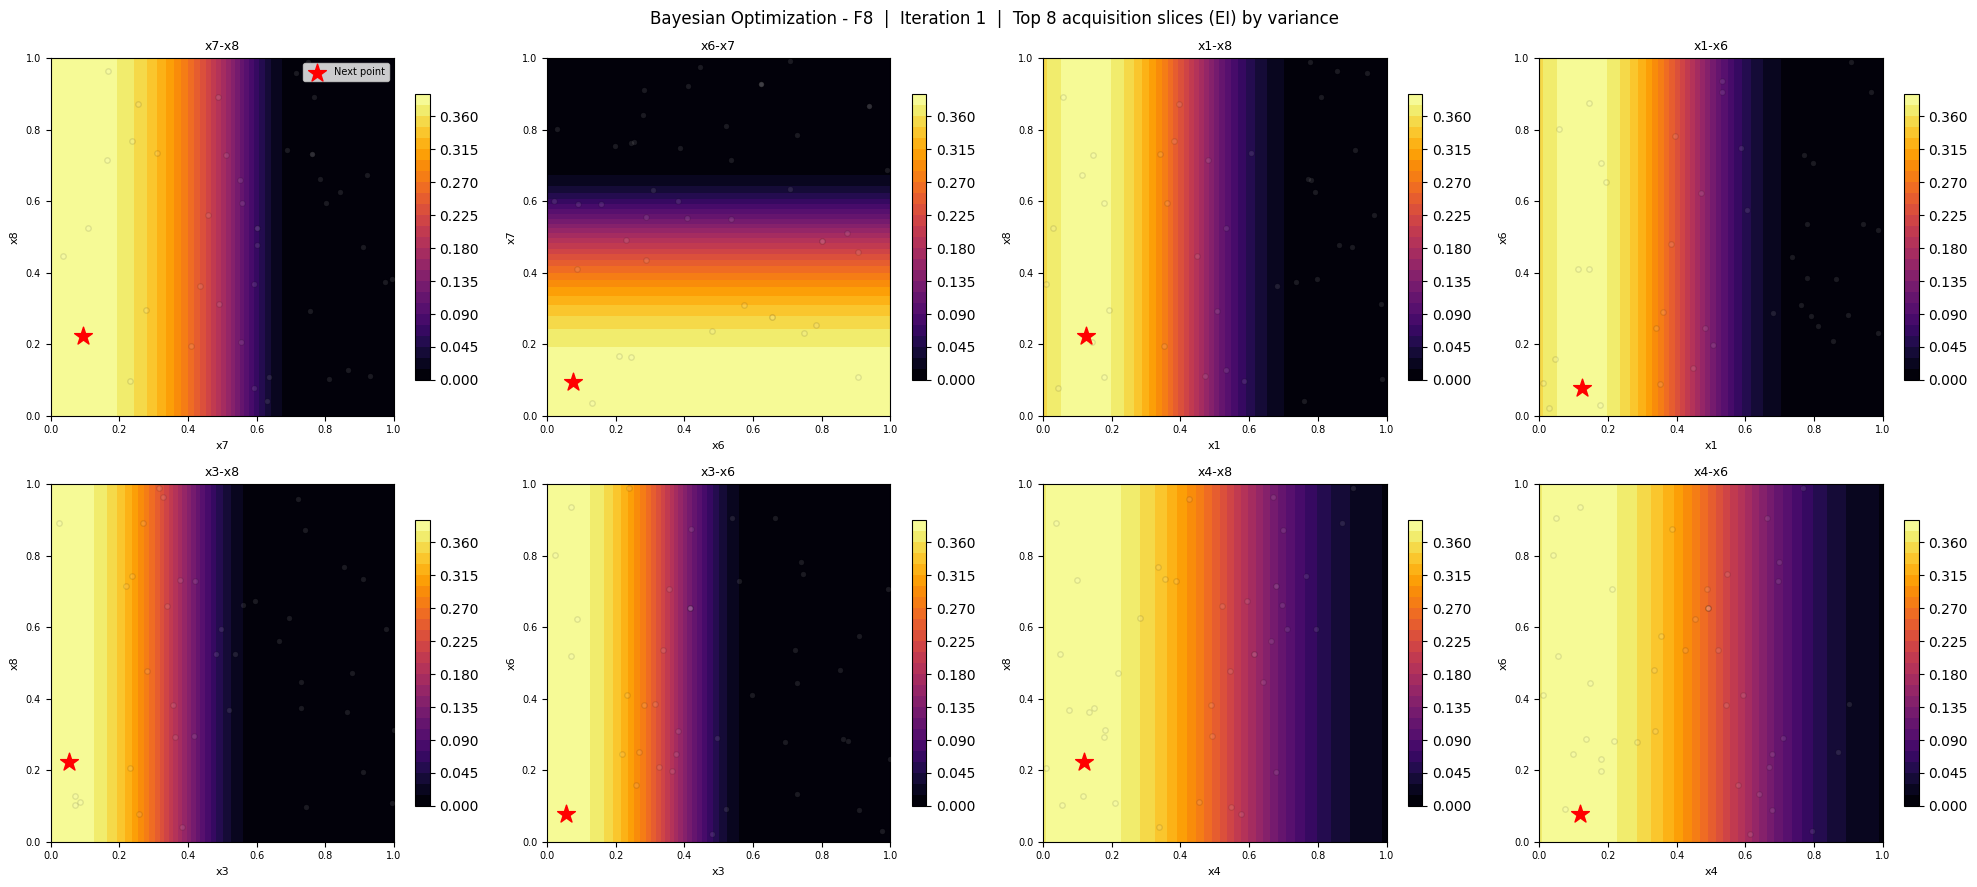

C:\Users\fakep\AppData\Local\Temp\ipykernel_33364\169679241.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   2  |  xi = 0.08500  |  acq = EI
  Current best y  : 9.896028
  ✅ Suggested x CAPSTONE       : 0.053628-0.352331-0.0-0.241356-1.0-0.629608-0.103803-1.0
  Suggested x     : [0.053628, 0.352331, 0.0, 0.241356, 1.0, 0.629608, 0.103803, 1.0]
  Acq. score      : 0.082120

  Top 8 most informative dimension pairs (ranked by acq. variance):
     1. x6-x7
     2. x7-x8
     3. x1-x6
     4. x1-x8
     5. x4-x6
     6. x2-x7
     7. x4-x8
     8. x1-x2


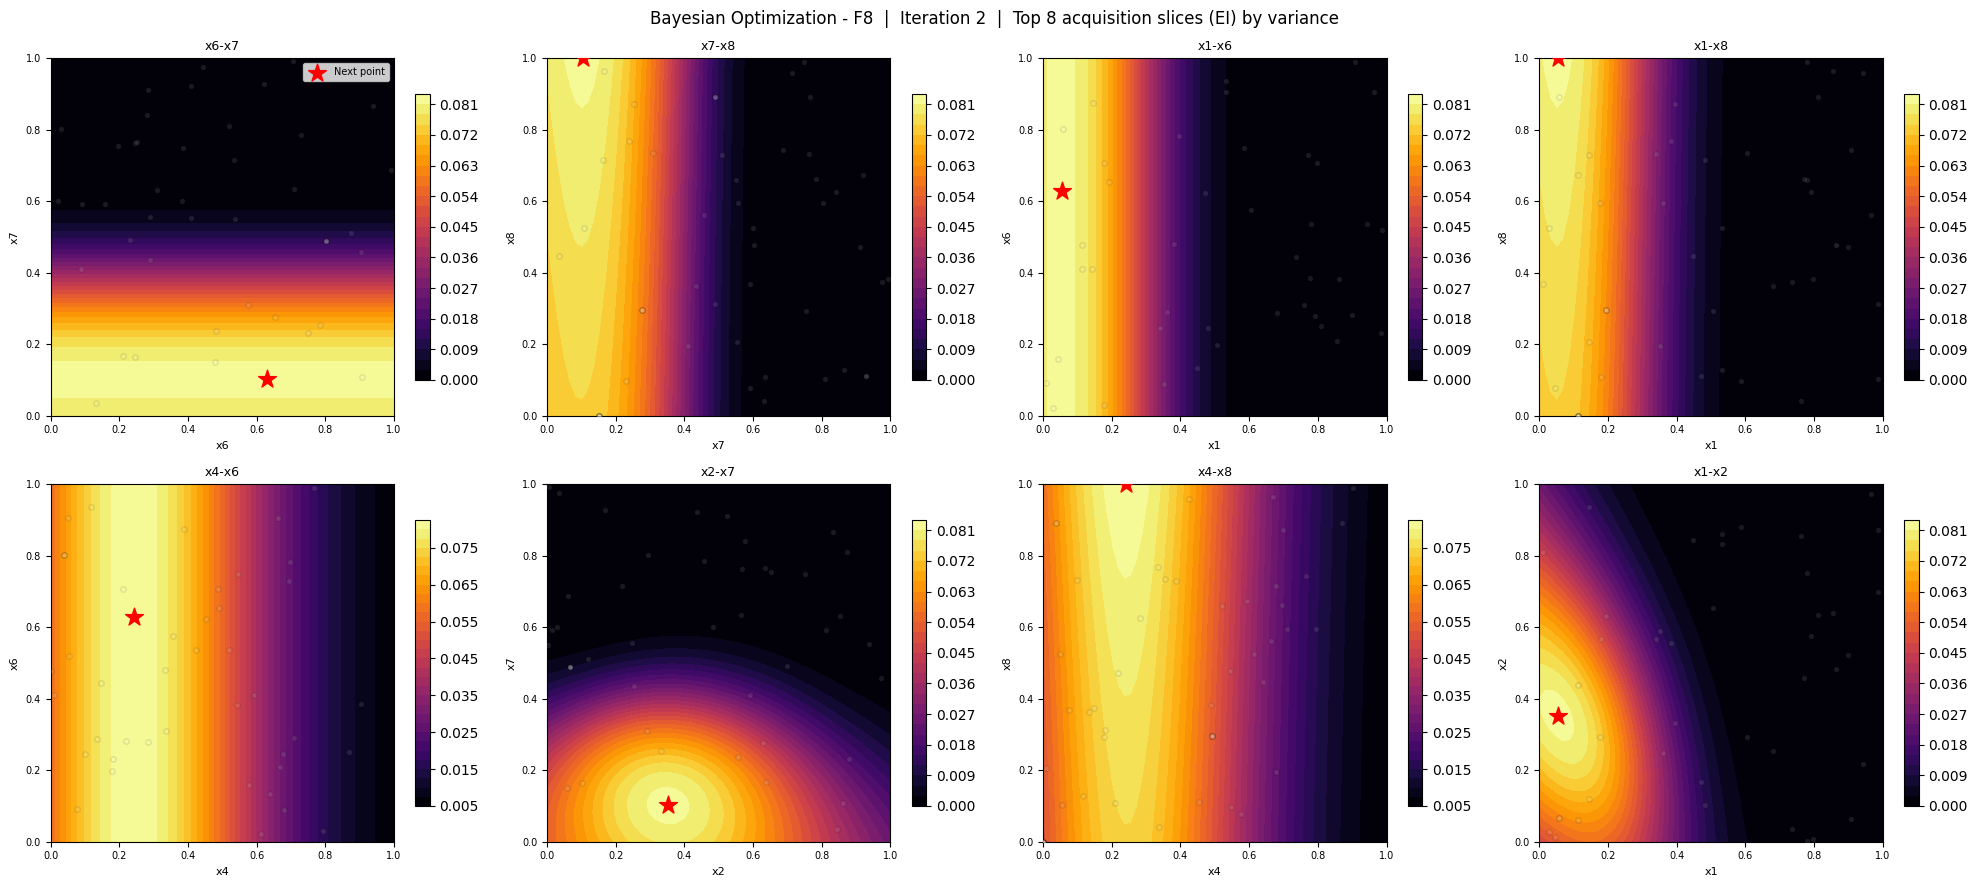

C:\Users\fakep\AppData\Local\Temp\ipykernel_33364\169679241.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   3  |  xi = 0.07225  |  acq = EI
  Current best y  : 9.896028
  ✅ Suggested x CAPSTONE       : 0.194909-0.246823-0.046751-0.167653-1.0-0.429364-0.203164-0.677782
  Suggested x     : [0.194909, 0.246823, 0.046751, 0.167653, 1.0, 0.429364, 0.203164, 0.677782]
  Acq. score      : 0.040869

  Top 8 most informative dimension pairs (ranked by acq. variance):
     1. x4-x6
     2. x4-x8
     3. x6-x7
     4. x7-x8
     5. x2-x6
     6. x2-x8
     7. x1-x6
     8. x1-x8


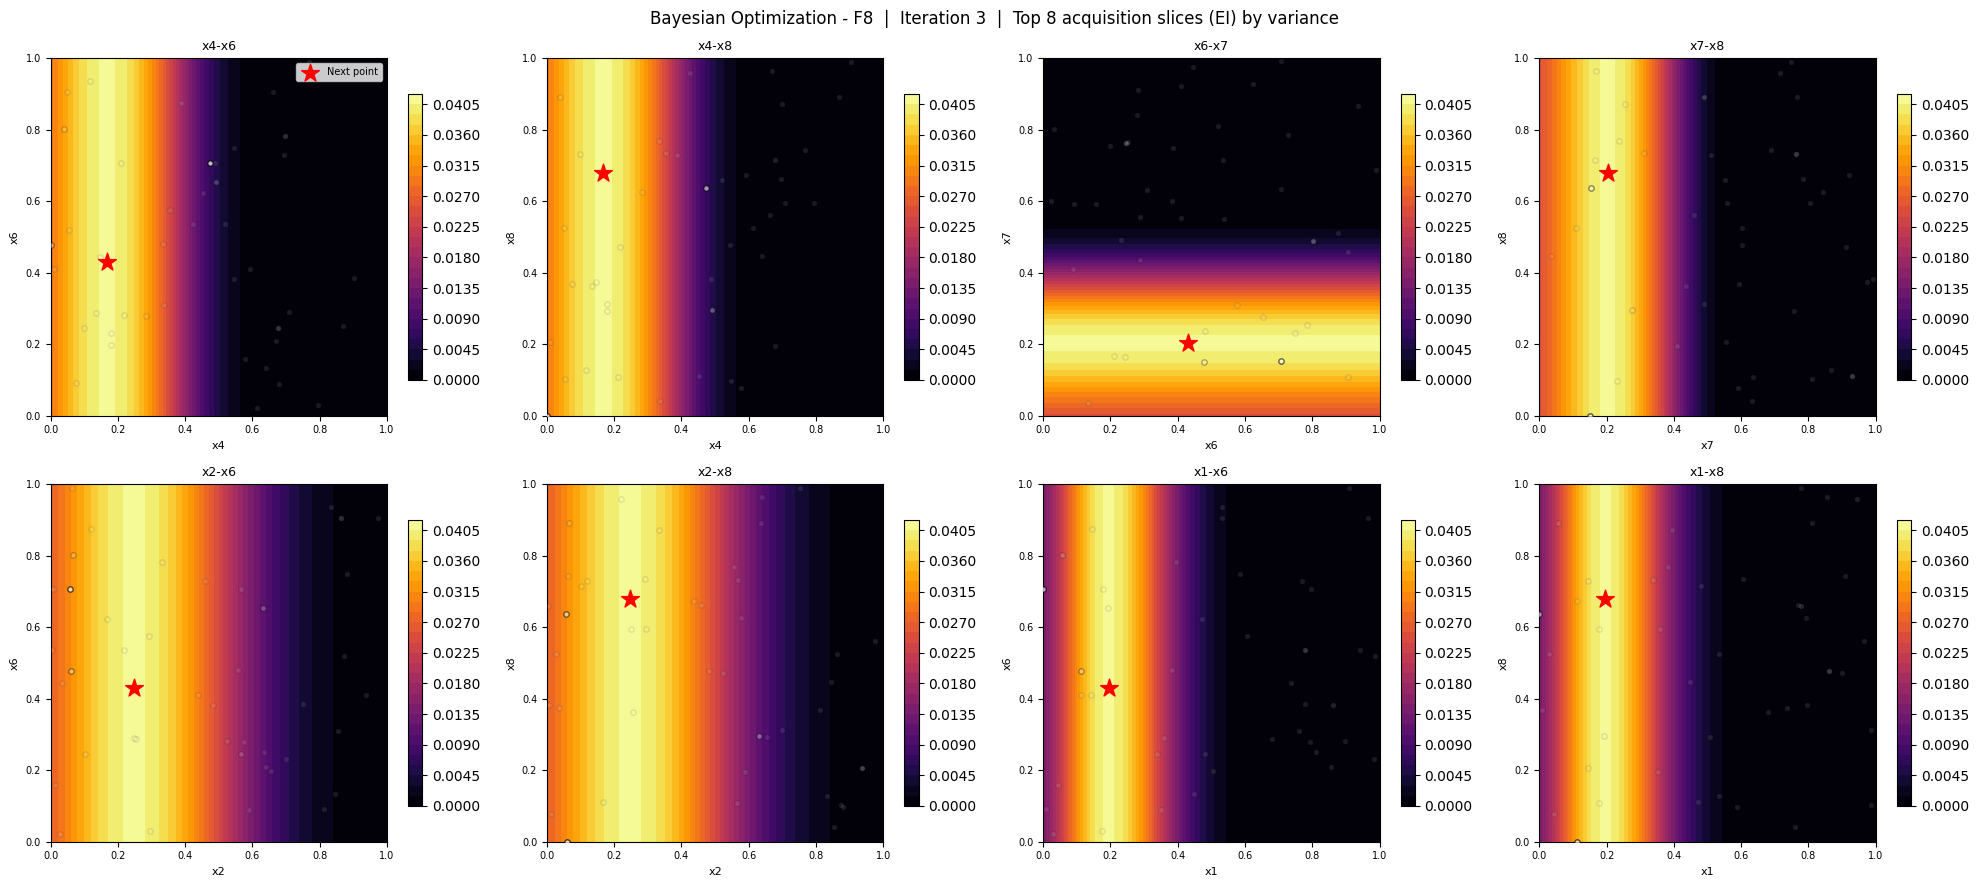

C:\Users\fakep\AppData\Local\Temp\ipykernel_33364\169679241.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   4  |  xi = 0.06141  |  acq = EI
  Current best y  : 9.912835
  ✅ Suggested x CAPSTONE       : 0.119578-0.169036-0.151337-0.118083-1.0-0.527856-0.309906-1.0
  Suggested x     : [0.119578, 0.169036, 0.151337, 0.118083, 1.0, 0.527856, 0.309906, 1.0]
  Acq. score      : 0.007162

  Top 8 most informative dimension pairs (ranked by acq. variance):
     1. x4-x8
     2. x2-x8
     3. x1-x8
     4. x6-x8
     5. x7-x8
     6. x2-x4
     7. x4-x6
     8. x2-x6


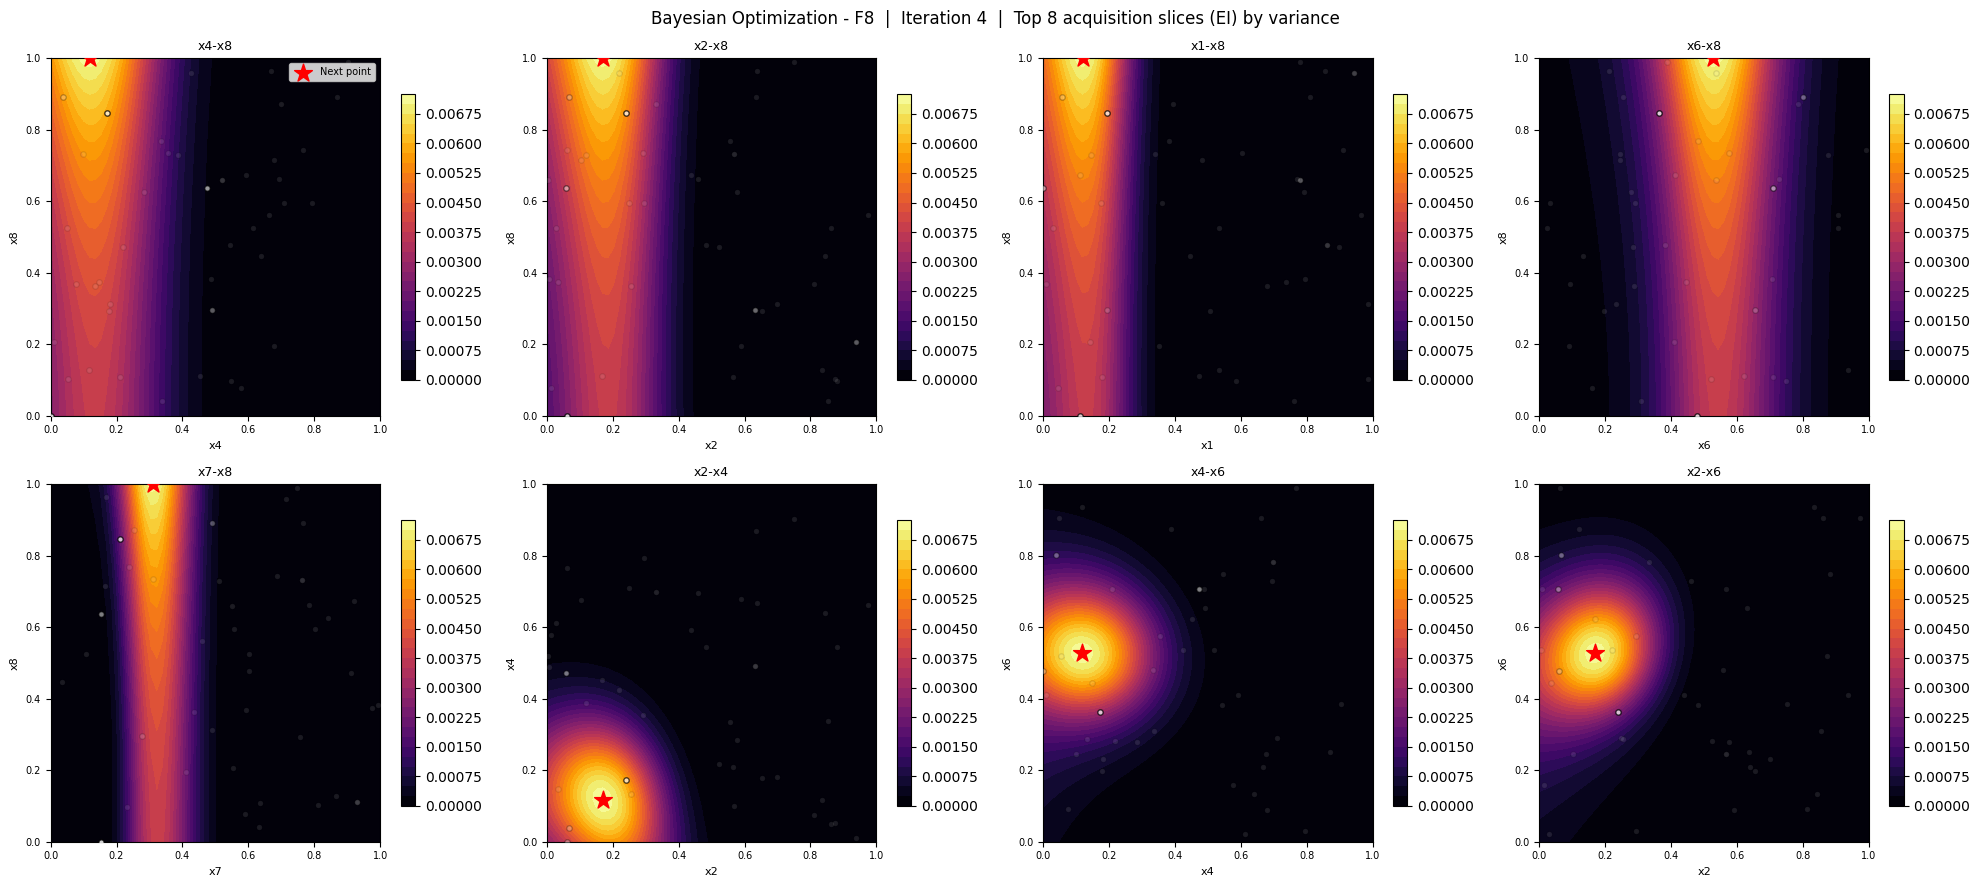

C:\Users\fakep\AppData\Local\Temp\ipykernel_33364\169679241.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   5  |  xi = 0.05220  |  acq = EI
  Current best y  : 9.912835
  ✅ Suggested x CAPSTONE       : 0.222597-0.0-0.152535-0.196438-1.0-0.103072-0.235415-0.938462
  Suggested x     : [0.222597, 0.0, 0.152535, 0.196438, 1.0, 0.103072, 0.235415, 0.938462]
  Acq. score      : 0.017926

  Top 8 most informative dimension pairs (ranked by acq. variance):
     1. x4-x6
     2. x4-x8
     3. x6-x7
     4. x7-x8
     5. x3-x6
     6. x3-x8
     7. x1-x6
     8. x1-x8


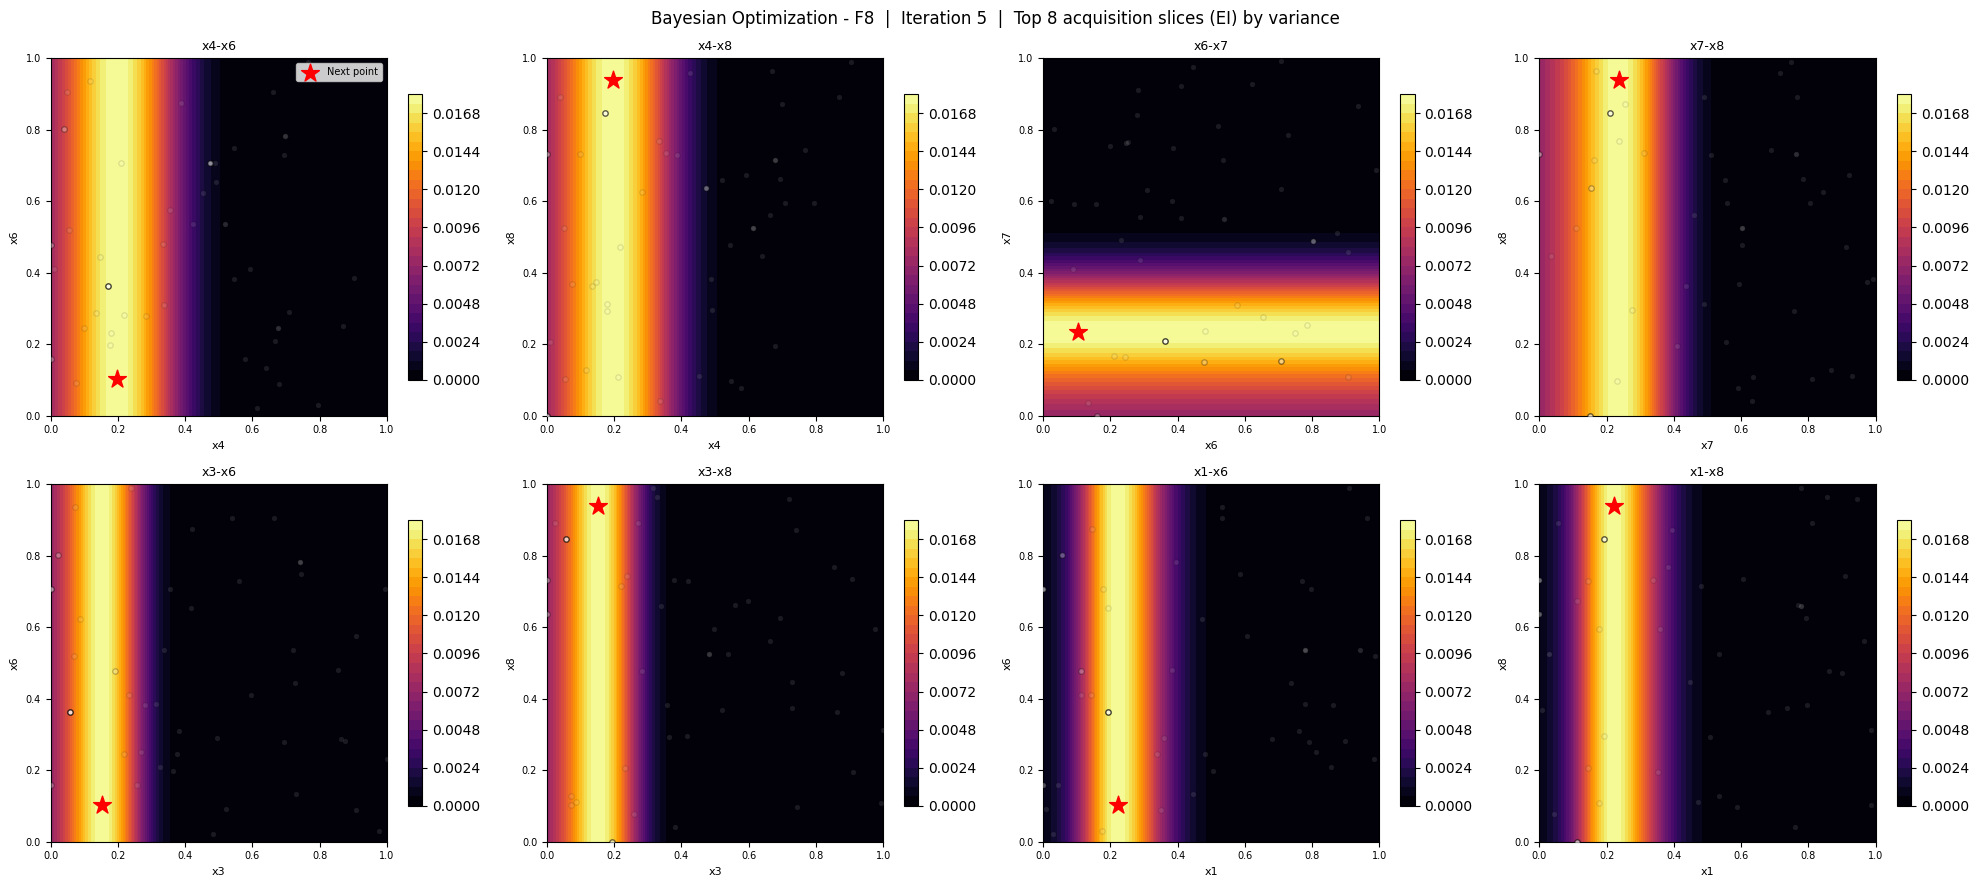

C:\Users\fakep\AppData\Local\Temp\ipykernel_33364\169679241.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   6  |  xi = 0.04437  |  acq = EI
  Current best y  : 9.912835
  ✅ Suggested x CAPSTONE       : 0.113927-0.202069-0.140407-0.098918-1.0-0.530991-0.305145-0.958559
  Suggested x     : [0.113927, 0.202069, 0.140407, 0.098918, 1.0, 0.530991, 0.305145, 0.958559]
  Acq. score      : 0.011297

  Top 8 most informative dimension pairs (ranked by acq. variance):
     1. x4-x8
     2. x2-x8
     3. x6-x8
     4. x1-x8
     5. x7-x8
     6. x3-x8
     7. x4-x6
     8. x2-x4


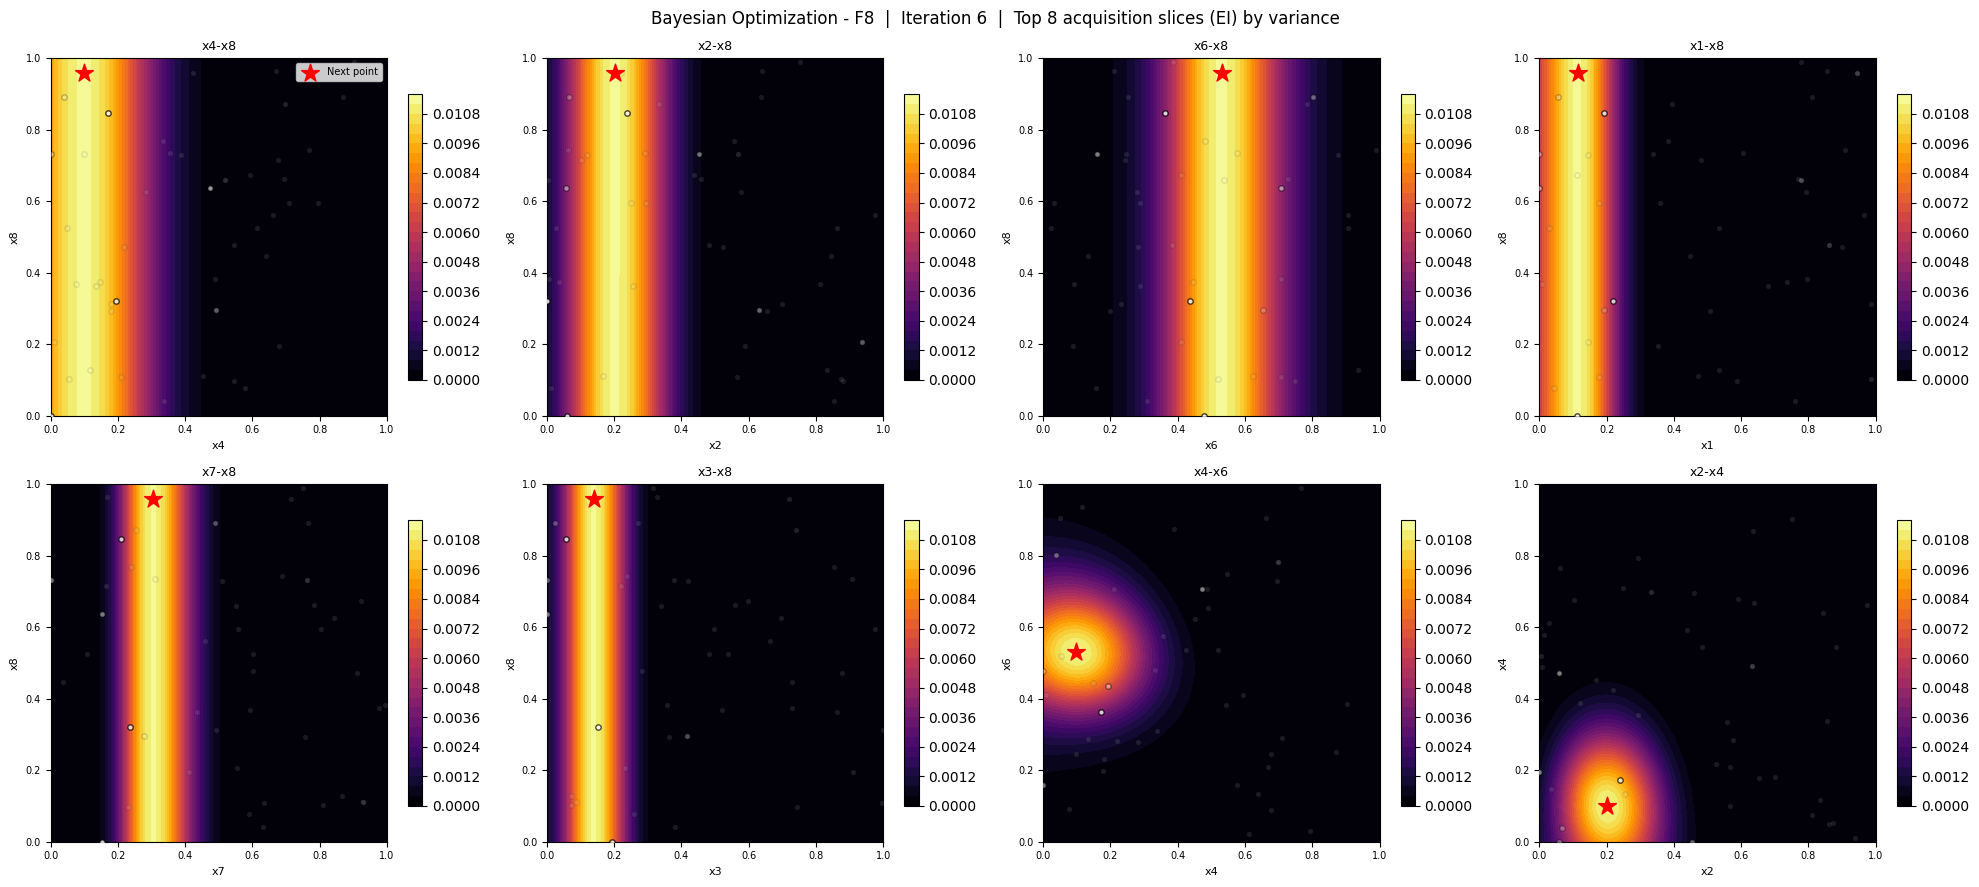

C:\Users\fakep\AppData\Local\Temp\ipykernel_33364\169679241.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   7  |  xi = 0.03771  |  acq = EI
  Current best y  : 9.912835
  ✅ Suggested x CAPSTONE       : 0.12887-0.15503-0.140785-0.141848-1.0-0.502625-0.240691-1.0
  Suggested x     : [0.12887, 0.15503, 0.140785, 0.141848, 1.0, 0.502625, 0.240691, 1.0]
  Acq. score      : 0.017628

  Top 8 most informative dimension pairs (ranked by acq. variance):
     1. x4-x8
     2. x2-x8
     3. x6-x8
     4. x2-x4
     5. x4-x6
     6. x1-x8
     7. x2-x6
     8. x7-x8


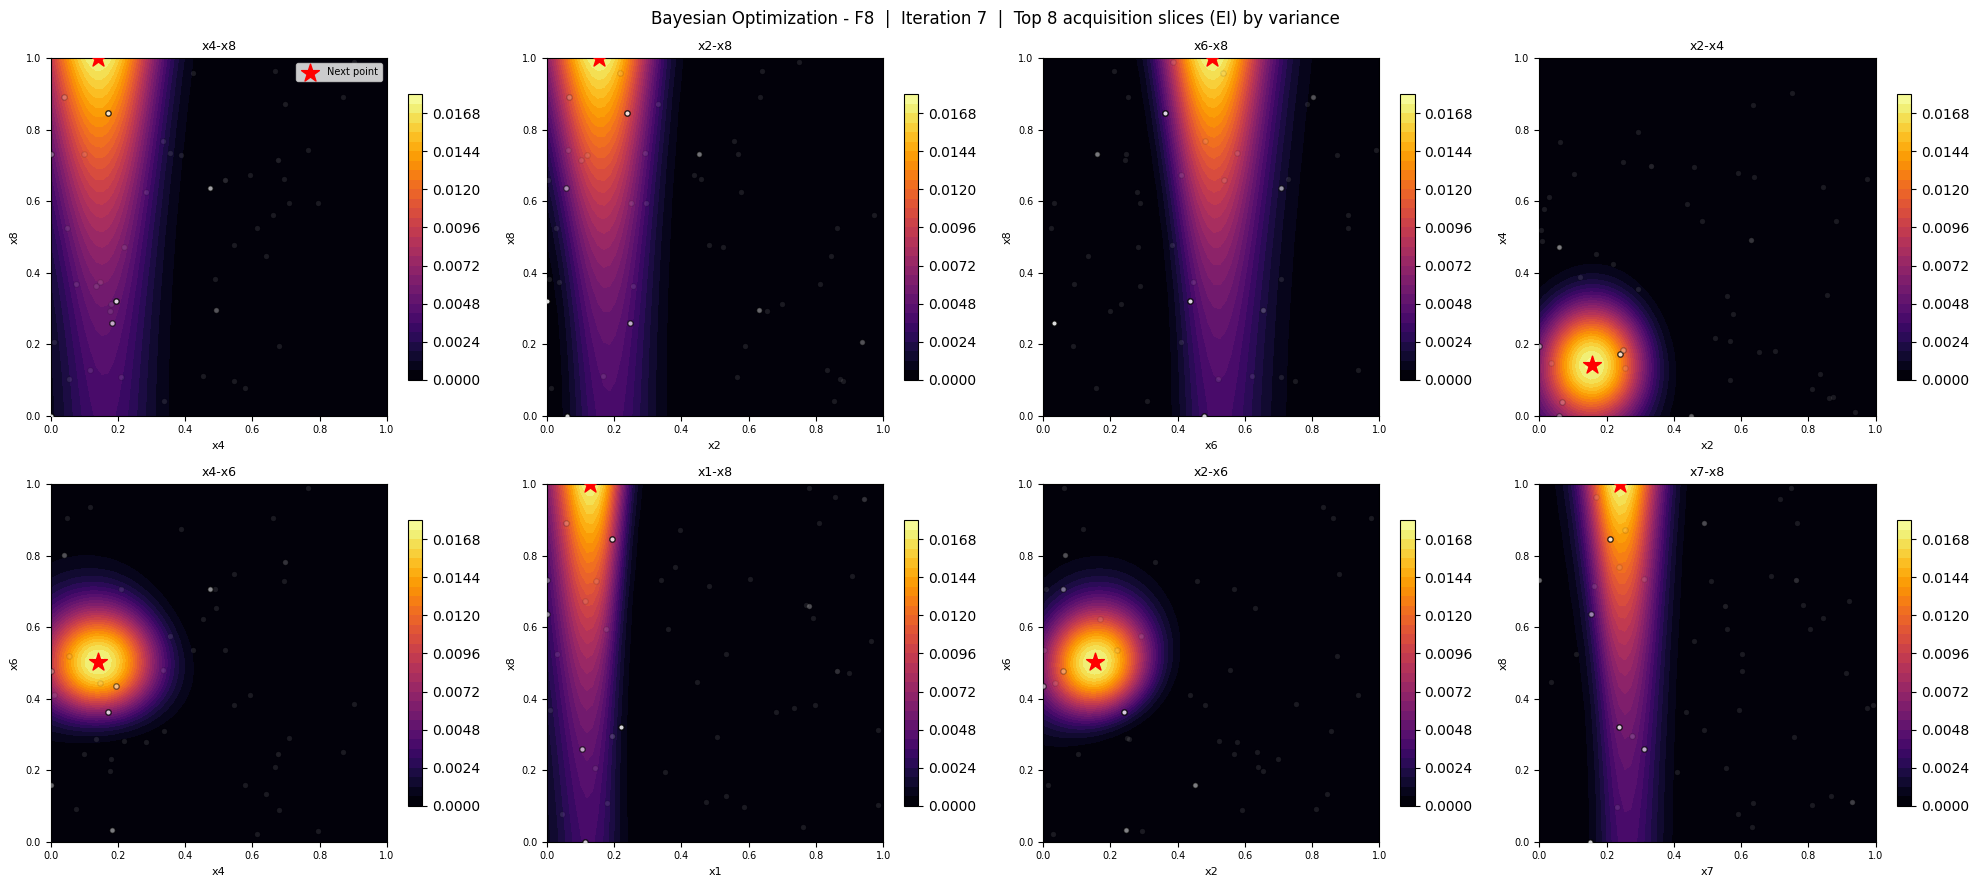

C:\Users\fakep\AppData\Local\Temp\ipykernel_33364\169679241.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   8  |  xi = 0.03206  |  acq = EI
  Current best y  : 9.912835
  ✅ Suggested x CAPSTONE       : 0.123603-0.164651-0.139785-0.171333-1.0-0.500226-0.236005-1.0
  Suggested x     : [0.123603, 0.164651, 0.139785, 0.171333, 1.0, 0.500226, 0.236005, 1.0]
  Acq. score      : 0.026023

  Top 8 most informative dimension pairs (ranked by acq. variance):
     1. x4-x8
     2. x2-x8
     3. x6-x8
     4. x1-x8
     5. x5-x8
     6. x7-x8
     7. x3-x8
     8. x2-x4


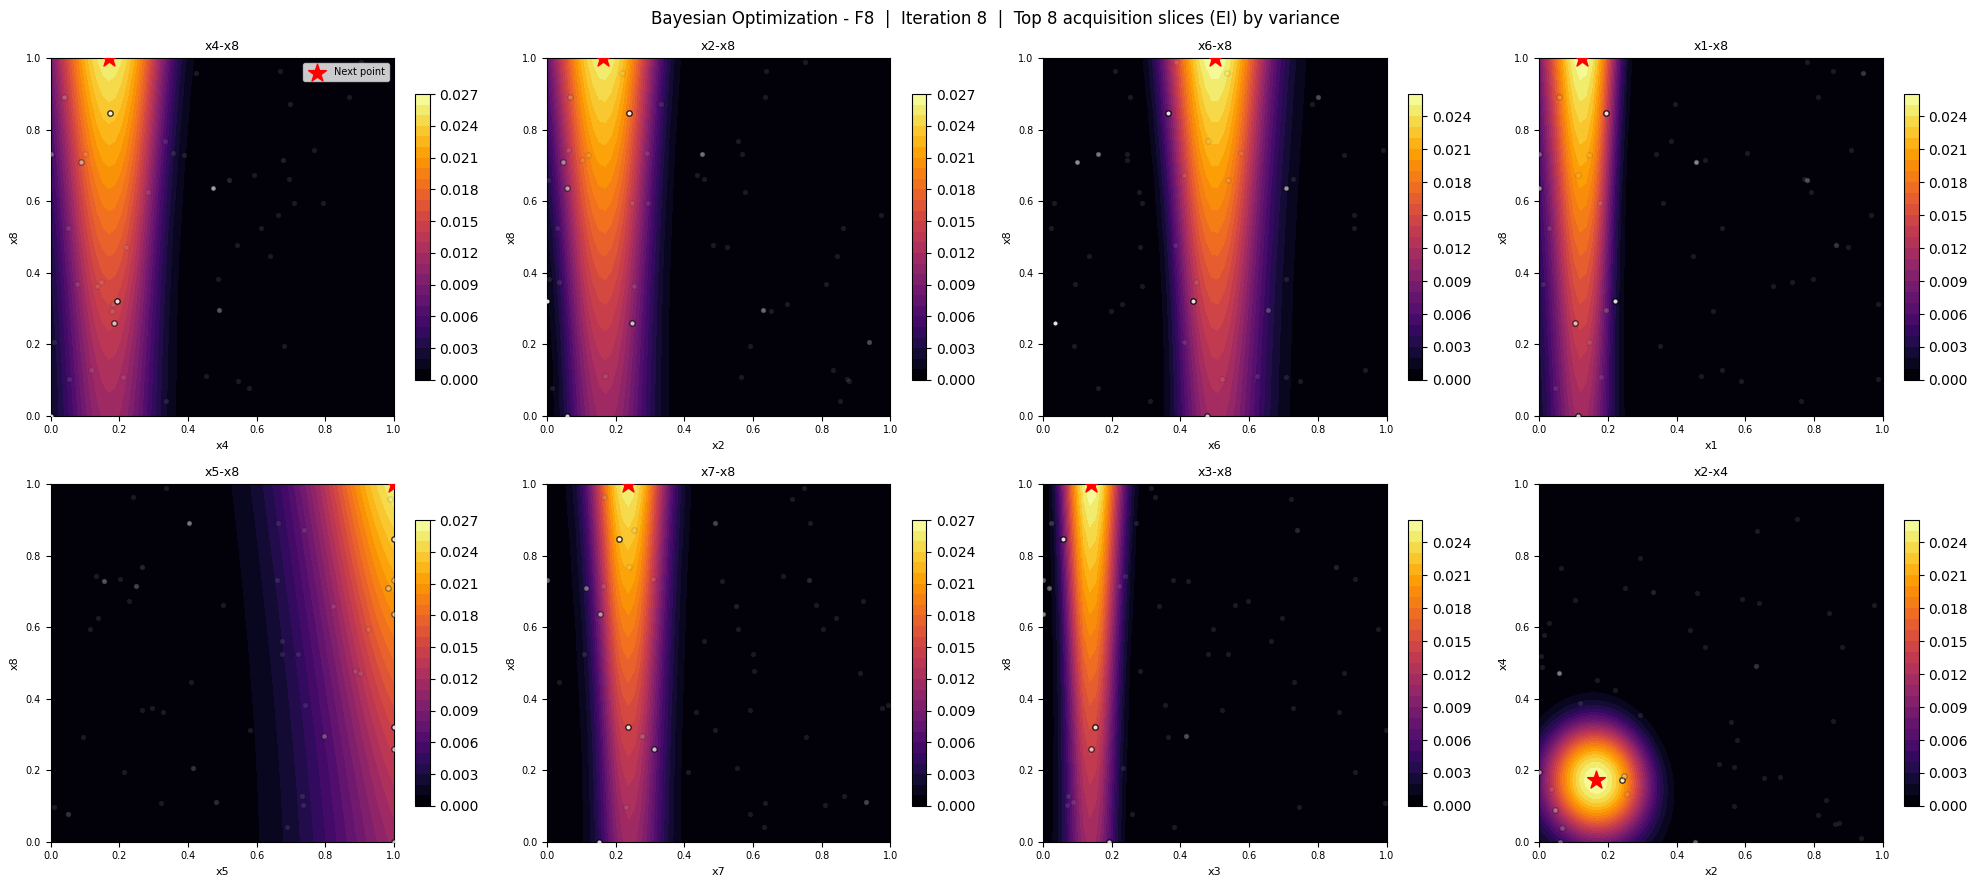

C:\Users\fakep\AppData\Local\Temp\ipykernel_33364\169679241.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   9  |  xi = 0.02725  |  acq = EI
  Current best y  : 9.959324
  ✅ Suggested x CAPSTONE       : 0.128673-0.168658-0.131978-0.168662-0.72714-0.496468-0.186874-0.713852
  Suggested x     : [0.128673, 0.168658, 0.131978, 0.168662, 0.72714, 0.496468, 0.186874, 0.713852]
  Acq. score      : 0.000251

  Top 8 most informative dimension pairs (ranked by acq. variance):
     1. x5-x8
     2. x4-x8
     3. x6-x8
     4. x2-x8
     5. x7-x8
     6. x1-x8
     7. x3-x8
     8. x4-x5


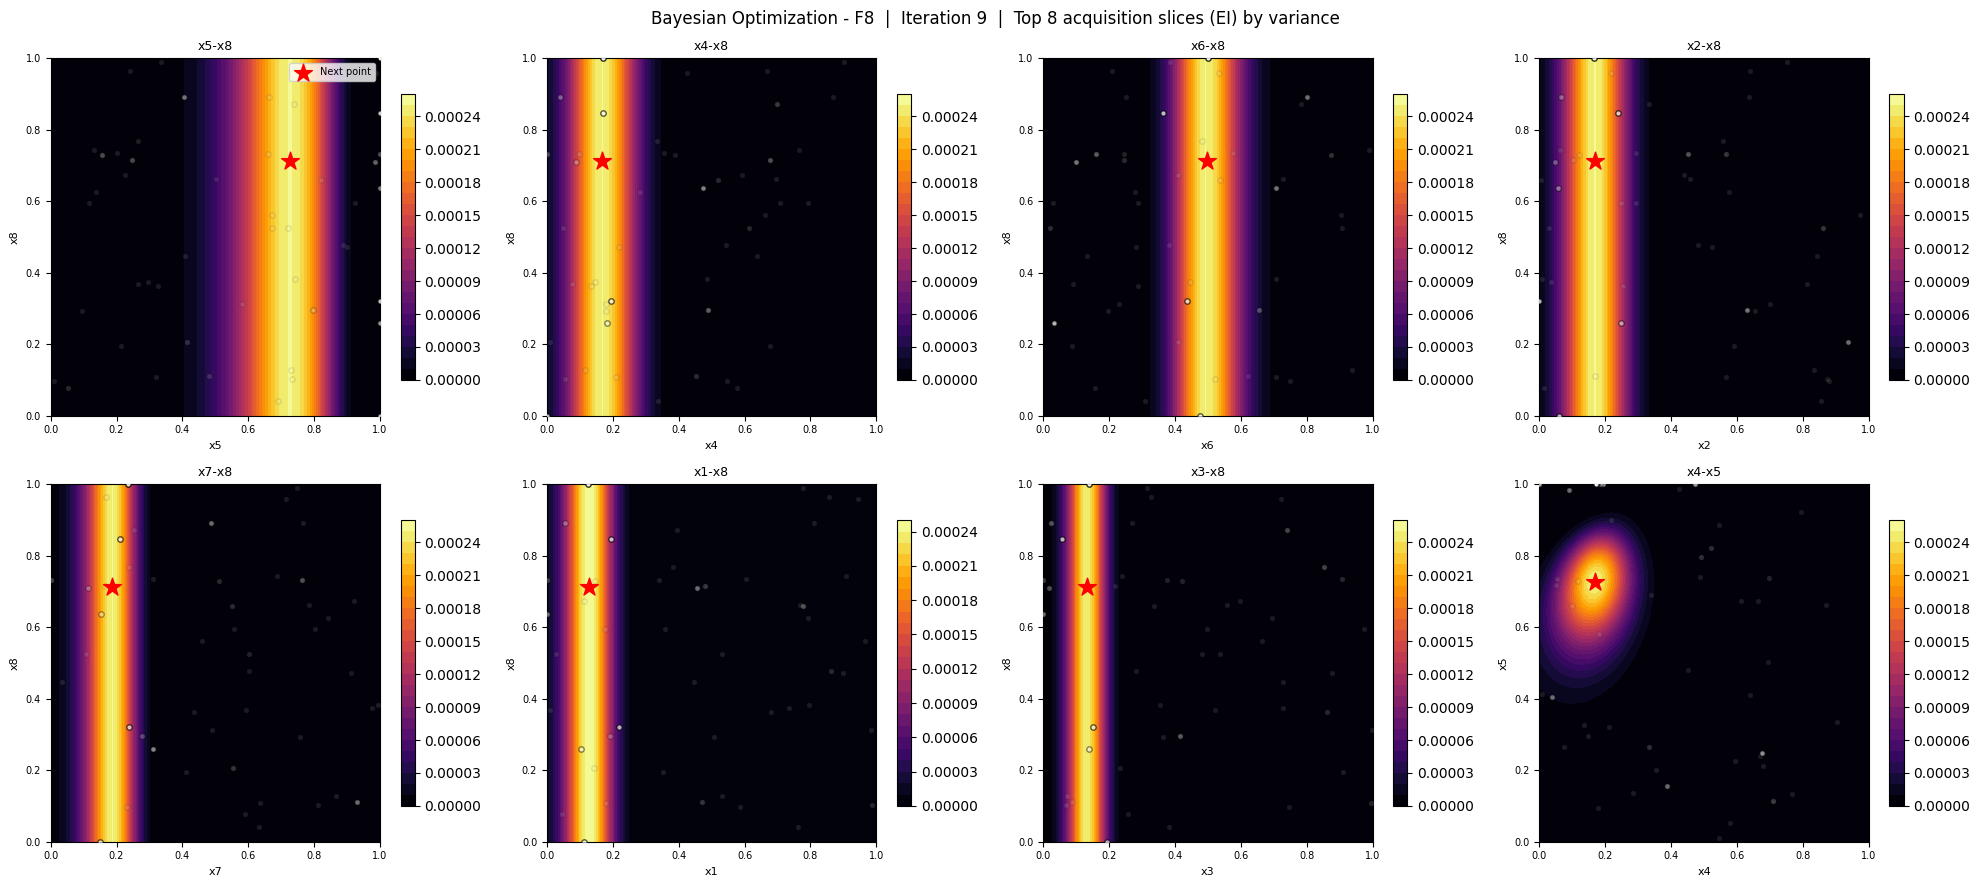

C:\Users\fakep\AppData\Local\Temp\ipykernel_33364\169679241.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  10  |  xi = 0.02316  |  acq = EI
  Current best y  : 9.993340
  ✅ Suggested x CAPSTONE       : 0.165323-0.167722-0.099052-0.079602-0.778291-0.644477-0.087535-0.301835
  Suggested x     : [0.165323, 0.167722, 0.099052, 0.079602, 0.778291, 0.644477, 0.087535, 0.301835]
  Acq. score      : 0.000000

  Top 8 most informative dimension pairs (ranked by acq. variance):
     1. x4-x8
     2. x4-x5
     3. x4-x6
     4. x2-x4
     5. x4-x7
     6. x6-x8
     7. x3-x4
     8. x1-x4


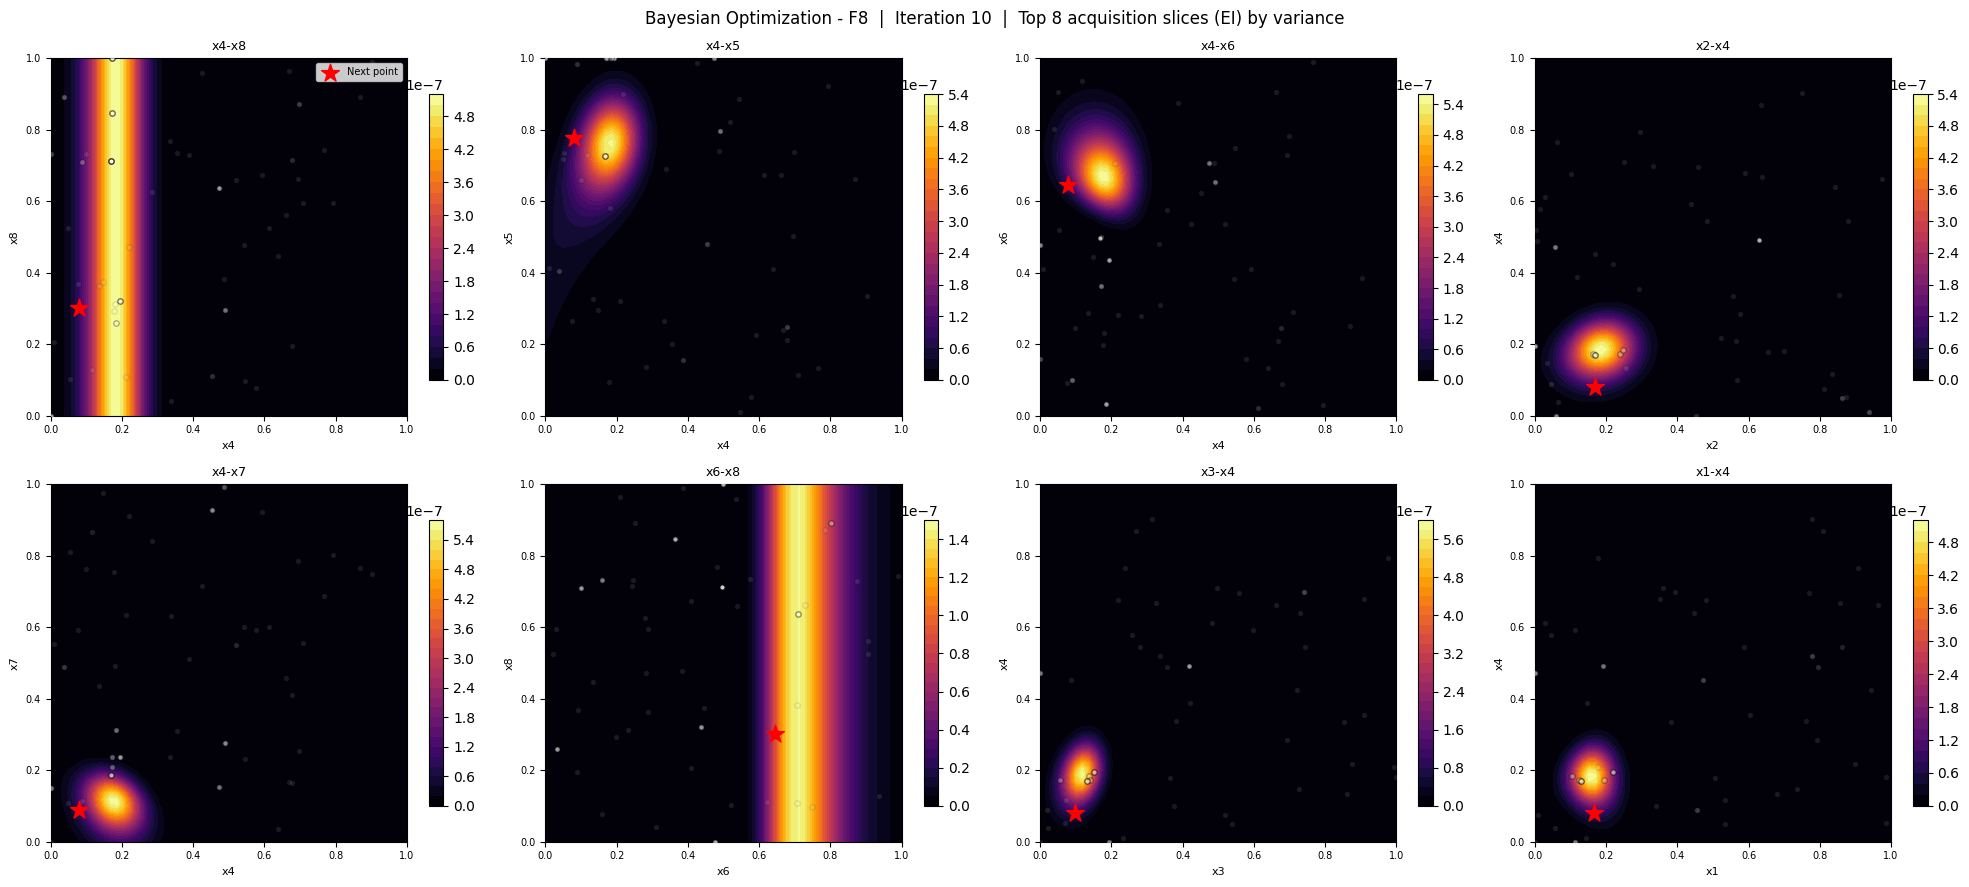

C:\Users\fakep\AppData\Local\Temp\ipykernel_33364\169679241.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  11  |  xi = 0.01969  |  acq = EI
  Current best y  : 9.993340
  ✅ Suggested x CAPSTONE       : 0.102214-0.233704-0.180155-0.282306-0.815512-0.507222-0.143754-0.725635
  Suggested x     : [0.102214, 0.233704, 0.180155, 0.282306, 0.815512, 0.507222, 0.143754, 0.725635]
  Acq. score      : 0.000000

  Top 8 most informative dimension pairs (ranked by acq. variance):
     1. x2-x8
     2. x7-x8
     3. x6-x8
     4. x2-x6
     5. x2-x7
     6. x6-x7
     7. x4-x8
     8. x1-x8


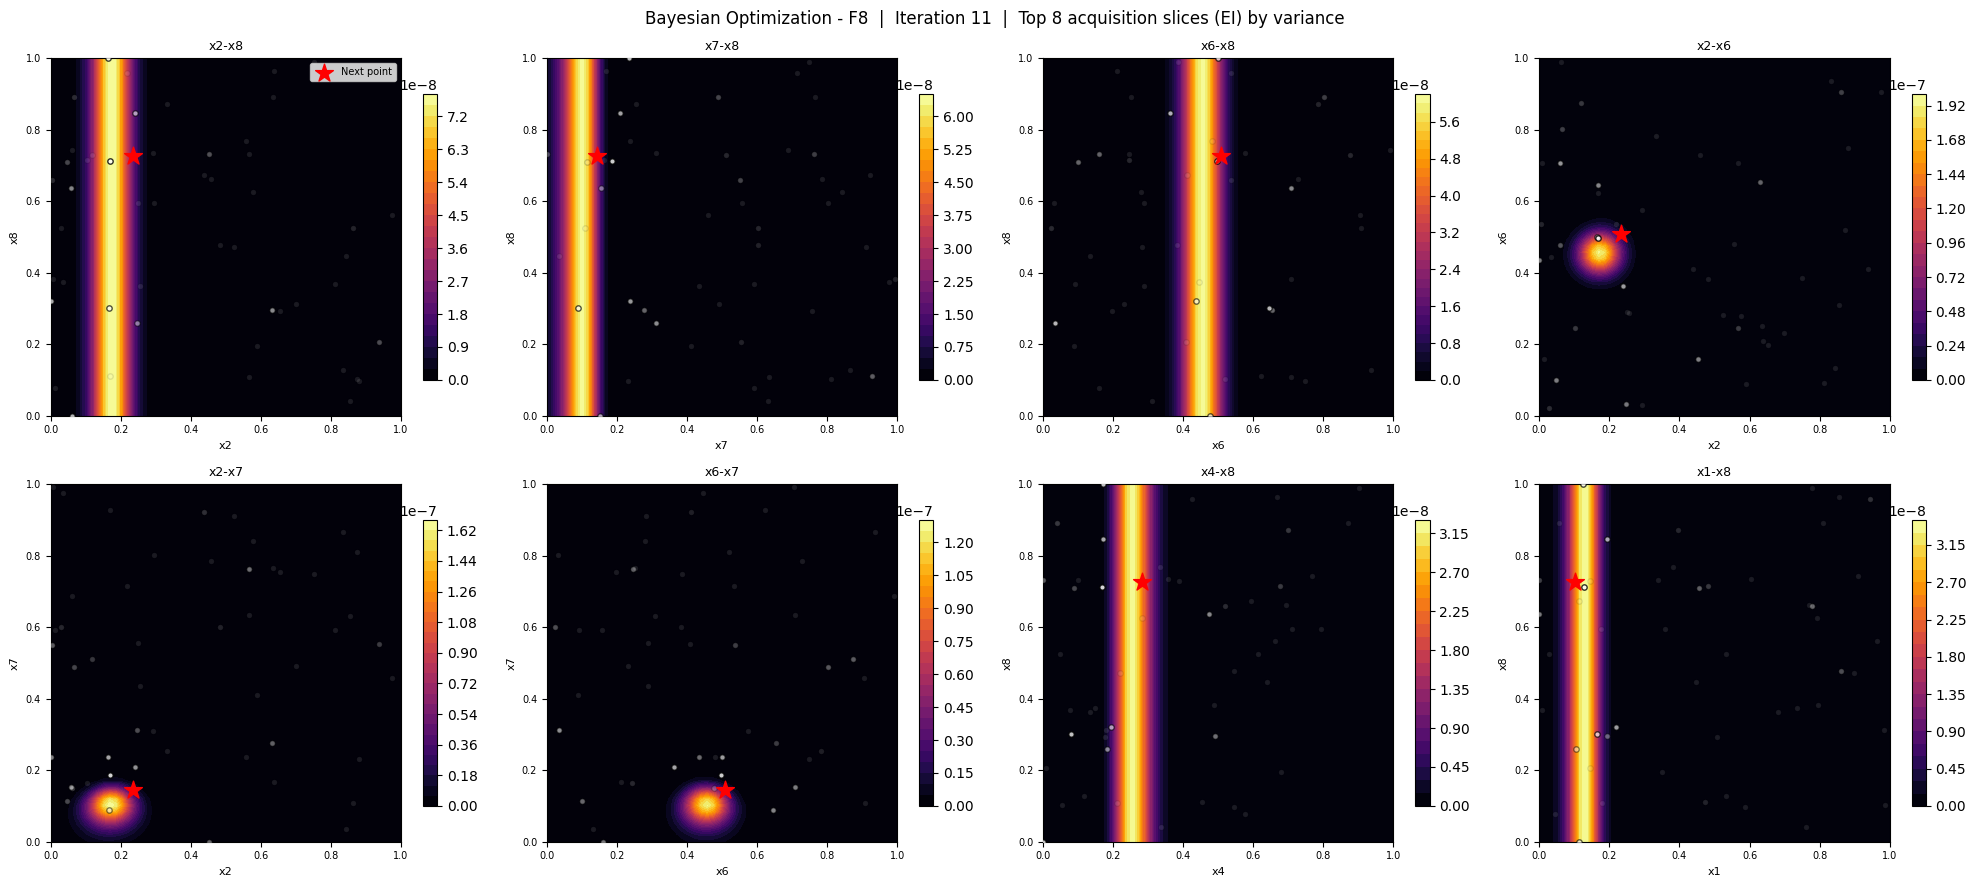

C:\Users\fakep\AppData\Local\Temp\ipykernel_33364\169679241.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  12  |  xi = 0.01673  |  acq = EI
  Current best y  : 9.993340
  ✅ Suggested x CAPSTONE       : 0.013779-0.045834-0.151199-0.183697-0.702664-0.499679-0.145978-0.205788
  Suggested x     : [0.013779, 0.045834, 0.151199, 0.183697, 0.702664, 0.499679, 0.145978, 0.205788]
  Acq. score      : 0.000000

  Top 8 most informative dimension pairs (ranked by acq. variance):
     1. x3-x8
     2. x1-x3
     3. x3-x6
     4. x3-x5
     5. x2-x3
     6. x3-x4
     7. x3-x7
     8. x1-x8


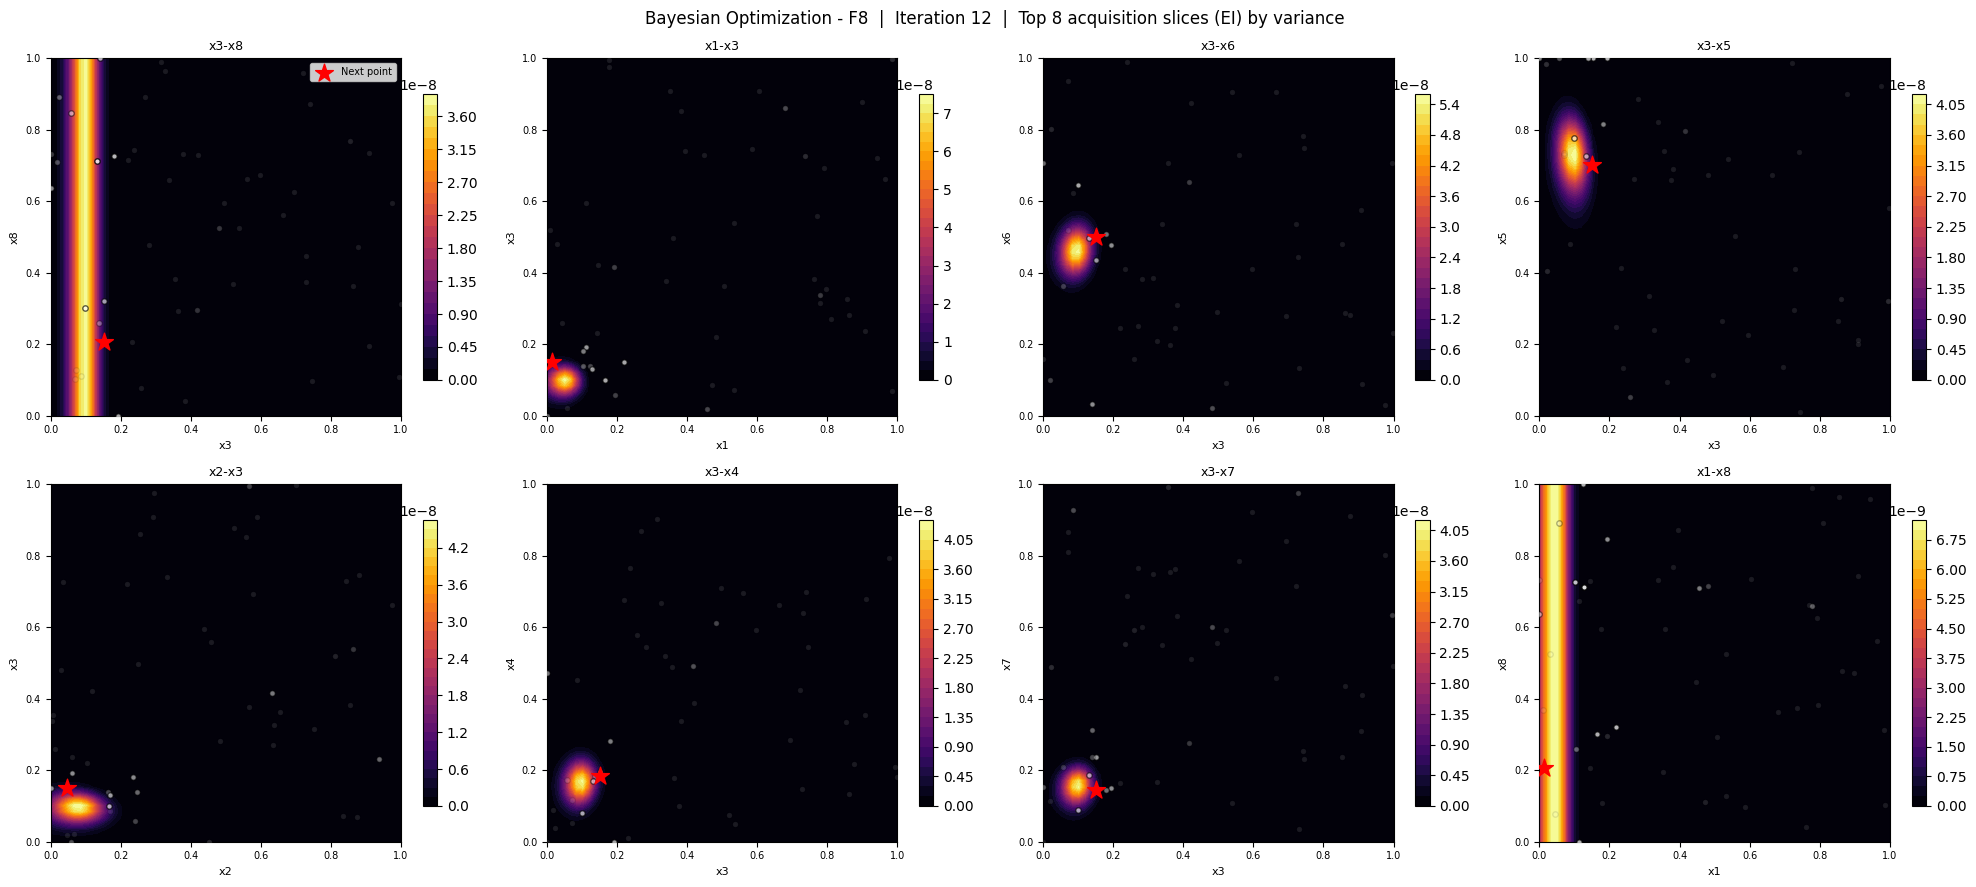

In [7]:
# ── Past Week Data ─────────────────────────────────────────────────────────────
X_new_Data = np.array([]).reshape(0, 8)
y_new_Data = np.array([])

# Week1 addition
X_new_Data = np.vstack([X_new_Data, [0.112879, 0.059596, 0.192484, 0.000000, 0.999999, 0.477350, 0.151309, 0.000000]])
y_new_Data = np.hstack([y_new_Data, 9.8960281792715])

# Week2 addition
X_new_Data = np.vstack([X_new_Data, [0.000000, 0.057852, 0.000000, 0.473397, 0.999999, 0.708066, 0.153845, 0.636600]])
y_new_Data = np.hstack([y_new_Data, 9.7485373420805])

# Week3 addition
X_new_Data = np.vstack([X_new_Data, [0.193197, 0.239542, 0.056717, 0.171757, 0.999999, 0.362760, 0.209845, 0.848241]])
y_new_Data = np.hstack([y_new_Data, 9.9128354822434])

# Week4 addition
X_new_Data = np.vstack([X_new_Data, [0.000000, 0.452264, 0.000000, 0.000000, 1.000000, 0.159618, 0.000000, 0.732930]])
y_new_Data = np.hstack([y_new_Data, 9.59780952989])

# Week5 addition
X_new_Data = np.vstack([X_new_Data, [0.219001, 0.000000, 0.151583, 0.193812, 1.000000, 0.435625, 0.236490, 0.320786]])
y_new_Data = np.hstack([y_new_Data, 9.9112573283824])

# Week6 addition
X_new_Data = np.vstack([X_new_Data, [0.103990, 0.247671, 0.138212, 0.183785, 1.000000, 0.033737, 0.311639, 0.260293]])
y_new_Data = np.hstack([y_new_Data, 9.7152169961061])

# Week7 addition
X_new_Data = np.vstack([X_new_Data, [0.456173, 0.046602, 0.018241, 0.089291, 0.983724, 0.099257, 0.114037, 0.709708]])
y_new_Data = np.hstack([y_new_Data, 9.5009795714126])

# Week8 addition
X_new_Data = np.vstack([X_new_Data, [0.124326, 0.164601, 0.139489, 0.171578, 1.000000, 0.499920, 0.235662, 1.000000]])
y_new_Data = np.hstack([y_new_Data, 9.959324005912])

# Week9 addition
X_new_Data = np.vstack([X_new_Data, [0.128673, 0.168658, 0.131978, 0.168662, 0.727140, 0.496468, 0.186874, 0.713852]])
y_new_Data = np.hstack([y_new_Data, 9.9933400131156])

# Week10 addition
X_new_Data = np.vstack([X_new_Data, [0.165323, 0.167722, 0.099052, 0.079602, 0.778291, 0.644477, 0.087535, 0.301835]])
y_new_Data = np.hstack([y_new_Data, 9.9280262945])

# Week12 addition
X_new_Data = np.vstack([X_new_Data, [0.102214, 0.233704, 0.180155, 0.282306, 0.815512, 0.507222, 0.143754, 0.725635]])
y_new_Data = np.hstack([y_new_Data, 9.9598542783705])

# Configuration
N_ITER   = len(y_new_Data)+1       # number of BO steps to run
ACQ      = "ei"    # "ei" or "ucb"
XI_INIT  = 0.1     # matches original F8 xi
XI_DECAY = 0.85
KAPPA    = 2.576   # only used if ACQ = "ucb"
N_TOP    = 8       # number of top slice pairs to visualise

# History (seeded with initial observations)
X_obs        = X.copy()
y_obs        = y.copy()
history_best = [y_obs.max()]

for iteration in range(N_ITER):

    # 1. Fit GP on raw outputs (no transform needed for F8)
    gp    = build_gp(n_dim)
    gp.fit(X_obs, y_obs)
    y_max = y_obs.max()

    # 2. Compute adaptive xi for this iteration
    xi = adaptive_xi(iteration, xi_init=XI_INIT, decay=XI_DECAY)

    # 3. Define acquisition callable for the plot helper
    if ACQ == "ucb":
        acq_fn    = lambda X_c: upper_confidence_bound(X_c, gp, kappa=KAPPA)
        acq_label = "UCB"
    else:
        acq_fn    = lambda X_c: expected_improvement(X_c, gp, y_max, xi=xi)
        acq_label = "EI"

    # 4. Suggest next point
    x_next, score = suggest_next_point(
        gp, y_max, n_dim,
        xi=xi, acq=ACQ, kappa=KAPPA,
        seed=SEED + iteration
    )

    # 5. Print summary
    print("\n" + "="*62)
    print(f"  Iteration {iteration + 1:>3d}  |  xi = {xi:.5f}  |  acq = {acq_label}")
    print(f"  Current best y  : {y_max:.6f}")
    print(f"  ✅ Suggested x CAPSTONE       : {np.round(x_next[0], 6)}-{np.round(x_next[1], 6)}-{np.round(x_next[2], 6)}-{np.round(x_next[3], 6)}-{np.round(x_next[4], 6)}-{np.round(x_next[5], 6)}-{np.round(x_next[6], 6)}-{np.round(x_next[7], 6)}")
    print(f"  Suggested x     : {np.round(x_next, 6).tolist()}")
    print(f"  Acq. score      : {score:.6f}")
    print("="*62)

    # 6. Visualise top-8 most informative acquisition slices
    plot_top_slices_8d(gp, X_obs, x_next, acq_fn,
                       iteration=iteration + 1, acq_label=acq_label, n_top=N_TOP)

    # ── PAST WEEKS DATA ──────────────────────────────────────────────
    if iteration < len(y_new_Data):
        y_new  = y_new_Data[iteration]
        X_obs  = np.vstack([X_obs, X_new_Data[iteration]])
        y_obs  = np.append(y_obs, y_new)
        history_best.append(y_obs.max())
    # ─────────────────────────────────────────────────────────────────────────

## 8. SVM classifier on observed data

In [8]:
# Threshold: top 25% of log-transformed observations = "high"
threshold = np.percentile(y_obs, 75)
labels = (y_obs >= threshold).astype(int)  # 1 = high, 0 = low

print(f"Threshold (75th pct, log-space): {threshold:.4f}")
print(f"High-performing points : {labels.sum()} / {len(labels)}")

# Scale inputs (SVM is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_obs)

# Soft-margin SVM with RBF kernel (handles non-linear boundaries)
# C controls margin softness: lower C = wider margin, more generalisation
# gamma='scale' = 1/(n_features * X.var()), a robust default
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm.fit(X_scaled, labels)

print(f"\nSVM kernel  : {svm.kernel}")
print(f"Support vectors : {svm.n_support_} (class 0 / class 1)")

Threshold (75th pct, log-space): 9.2636
High-performing points : 13 / 51

SVM kernel  : rbf
Support vectors : [17  9] (class 0 / class 1)


## 9. Visualise the SVM decision boundary alongside GP

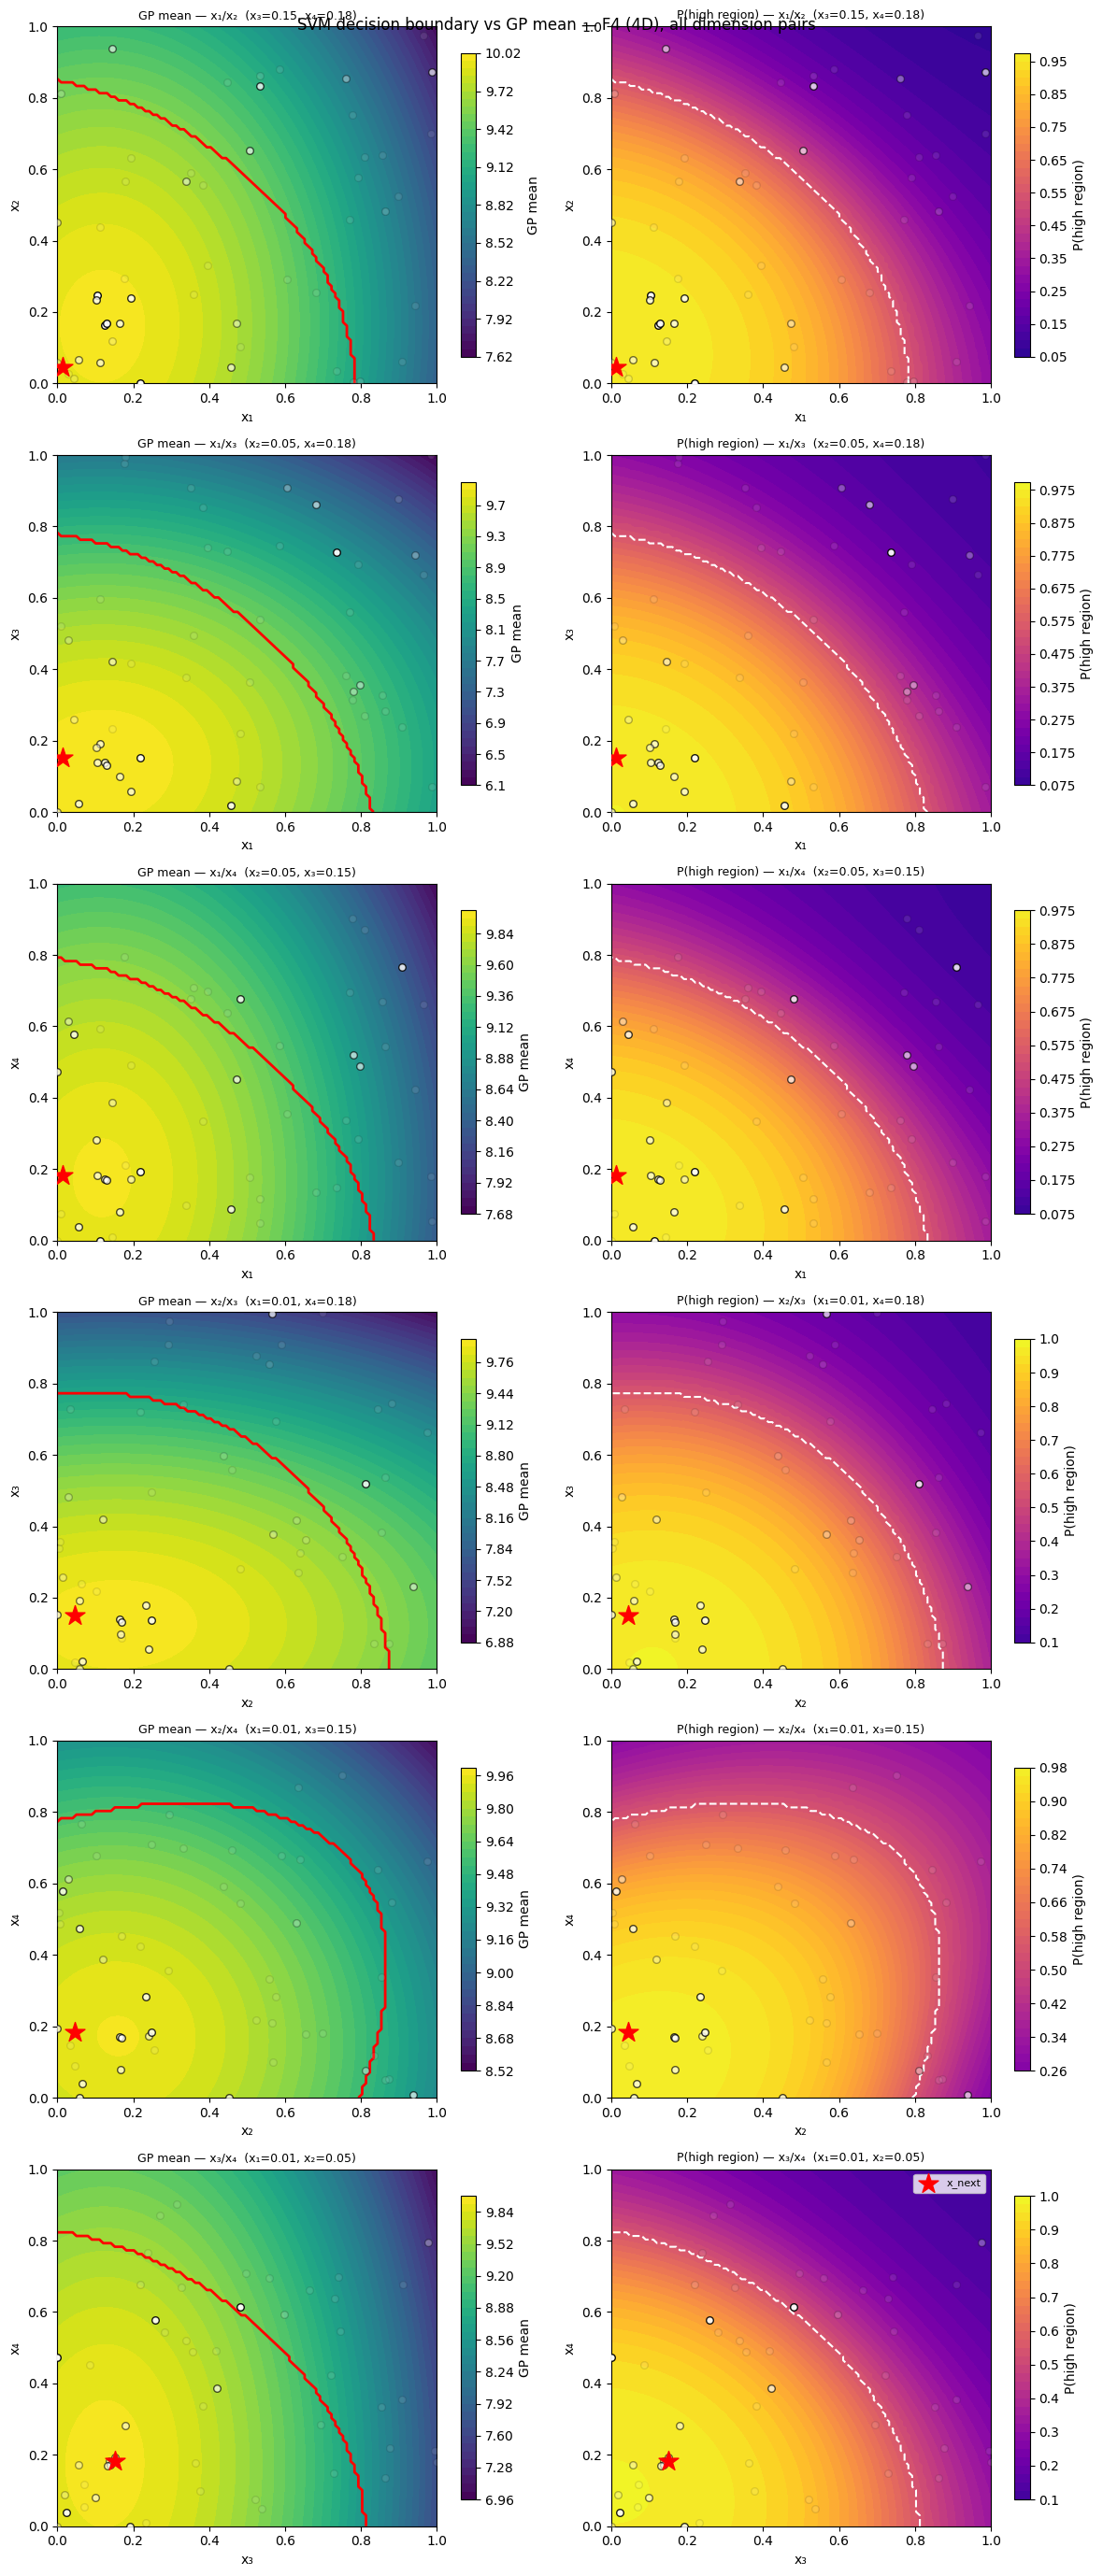

In [9]:
# ── Plot: SVM probability slices — all 6 dimension pairs (4D) ────────────────
from itertools import combinations

resolution = 100
grid_1d    = np.linspace(0, 1, resolution)
G1, G2     = np.meshgrid(grid_1d, grid_1d)
flat1, flat2 = G1.ravel(), G2.ravel()

dim_labels = ["x₁", "x₂", "x₃", "x₄"]
dim_pairs  = list(combinations(range(4), 2))   # 6 pairs

fig, axes = plt.subplots(6, 2, figsize=(12, 28))  # 6 rows × 2 cols
fig.suptitle("SVM decision boundary vs GP mean — F4 (4D), all dimension pairs", fontsize=12)

for row, (d0, d1) in enumerate(dim_pairs):
    fixed_dims = [d for d in range(4) if d not in (d0, d1)]

    # Build 4-column grid: sweep d0 & d1, fix the other two at x_next values
    X_grid = np.tile(x_next, (resolution * resolution, 1))
    X_grid[:, d0] = flat1
    X_grid[:, d1] = flat2

    # GP mean
    mu_slice, _ = gp.predict(X_grid, return_std=True)
    mu_slice     = mu_slice.reshape(resolution, resolution)

    # SVM predictions
    X_grid_scaled  = scaler.transform(X_grid)
    svm_prob_slice = svm.predict_proba(X_grid_scaled)[:, 1].reshape(resolution, resolution)
    svm_pred_slice = svm.predict(X_grid_scaled).reshape(resolution, resolution)

    # Opacity: average proximity across both fixed dims
    dist   = np.mean([np.abs(X_obs[:, fd] - x_next[fd]) for fd in fixed_dims], axis=0)
    alphas = np.clip(1.0 - dist / 0.3, 0.1, 1.0)
    fix_str = ", ".join(f"{dim_labels[fd]}={x_next[fd]:.2f}" for fd in fixed_dims)

    # Left column: GP mean + SVM boundary
    ax = axes[row, 0]
    im = ax.contourf(G1, G2, mu_slice, levels=40, cmap="viridis")
    fig.colorbar(im, ax=ax, shrink=0.85, label="GP mean")
    ax.contour(G1, G2, svm_pred_slice, levels=[0.5], colors="red", linewidths=2)
    for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black",
                   s=30, alpha=float(a), zorder=5)
    ax.scatter(x_next[d0], x_next[d1], c="red", marker="*", s=250, zorder=6)
    ax.set_title(f"GP mean — {dim_labels[d0]}/{dim_labels[d1]}  ({fix_str})", fontsize=9)
    ax.set_xlabel(dim_labels[d0]); ax.set_ylabel(dim_labels[d1])

    # Right column: SVM P(high)
    ax = axes[row, 1]
    im2 = ax.contourf(G1, G2, svm_prob_slice, levels=40, cmap="plasma", vmin=0, vmax=1)
    fig.colorbar(im2, ax=ax, shrink=0.85, label="P(high region)")
    ax.contour(G1, G2, svm_pred_slice, levels=[0.5], colors="white",
               linewidths=1.5, linestyles="--")
    for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black",
                   s=30, alpha=float(a), zorder=5)
    ax.scatter(x_next[d0], x_next[d1], c="red", marker="*", s=250,
               zorder=6, label="x_next")
    ax.set_title(f"P(high region) — {dim_labels[d0]}/{dim_labels[d1]}  ({fix_str})", fontsize=9)
    ax.set_xlabel(dim_labels[d0]); ax.set_ylabel(dim_labels[d1])

axes[-1, 1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("svm_boundary_f4.png", dpi=150)
plt.show()

## 10. SVM-constrained next point suggestion

In [10]:
# ── Constrained BO: suggest next point inside SVM "high" region ──────────────
from scipy.stats import qmc

# Generate a large Sobol candidate set
sampler = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 99)
X_cand = sampler.random(20_000)

# Keep only candidates the SVM classifies as "high"
X_cand_scaled = scaler.transform(X_cand)
svm_labels    = svm.predict(X_cand_scaled)
svm_probs     = svm.predict_proba(X_cand_scaled)[:, 1]

# Filter: inside SVM high region AND probability > 0.5
mask = (svm_labels == 1) & (svm_probs > 0.5)
X_constrained = X_cand[mask]

print(f"Candidates in high region : {mask.sum()} / {len(X_cand)} "
      f"({100*mask.mean():.1f}% of space)")

if len(X_constrained) < 10:
    # Fallback: boundary too restrictive, use full candidate set
    print("⚠️  Fewer than 10 constrained candidates — falling back to full set.")
    X_constrained = X_cand

# Score with EI inside the constrained region only
xi_constrained = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)
ei_scores = expected_improvement(X_constrained, gp, y_obs.max(), xi=xi_constrained)

# Local optimisation from top-8 starts within the constrained region
starts = X_constrained[np.argsort(ei_scores)[-8:]]
bounds = [(0, 1)] * n_dim
obj    = lambda x: -expected_improvement(x, gp, y_obs.max(), xi=xi_constrained).item()

best_x_svm, best_score_svm = None, -np.inf
for x0 in starts:
    res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")
    if -res.fun > best_score_svm:
        best_score_svm = -res.fun
        best_x_svm     = res.x

print(f"\n{'='*55}")
print(f"  SVM-constrained suggestion")
print(f"  Suggested x : {np.round(best_x_svm, 6).tolist()}")
print(f"  EI score    : {best_score_svm:.6f}")
print(f"  xi used     : {xi_constrained:.5f}")
print(f"  ✅ CAPSTONE format : {np.round(best_x_svm[0],6)}-{np.round(best_x_svm[1],6)}-{np.round(best_x_svm[2],6)}-{np.round(best_x_svm[3],6)}-{np.round(best_x_svm[4],6)}-{np.round(best_x_svm[5],6)}-{np.round(best_x_svm[6],6)}-{np.round(best_x_svm[7],6)}")
print(f"{'='*55}")

Candidates in high region : 499 / 20000 (2.5% of space)

  SVM-constrained suggestion
  Suggested x : [0.057917, 0.08159, 0.123439, 0.118729, 0.812278, 0.504814, 0.081656, 0.641662]
  EI score    : 0.000000
  xi used     : 0.01422
  ✅ CAPSTONE format : 0.057917-0.08159-0.123439-0.118729-0.812278-0.504814-0.081656-0.641662


C:\Users\fakep\AppData\Local\Temp\ipykernel_33364\3322772931.py:6: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand = sampler.random(20_000)


## 11. Neural Network Surrogate (MC Dropout)

We use a **PyTorch MLP with Monte Carlo Dropout** as a third surrogate. Unlike the GP (which has a closed-form posterior) or the SVM (which only classifies regions), the NN learns a direct regression mapping from input to output.

**Why MC Dropout for uncertainty?**
Dropout randomly zeroes neurons during training to prevent co-adaptation. At inference time, keeping dropout *active* and running multiple forward passes produces a distribution of predictions — the mean is the surrogate's prediction and the standard deviation is its uncertainty estimate (Gal & Ghahramani, 2016).

**Architecture:**
- 2 hidden layers of 32 units with ReLU activations
- Dropout rate = 0.1 between each layer
- Trained with Adam + L2 weight decay on normalised targets
- Uncertainty = std across 200 stochastic forward passes

> **F8 note:** 8D input, 43 training points, raw y values (normalised to N(0,1) for stable training). The visualisation uses the **same adaptive top-8 approach** as the GP — all 28 dimension pairs are scored by NN EI variance and the 8 most informative are shown in a 2×4 grid.

In [11]:
class MCDropoutNN(nn.Module):
    """MLP with dropout kept active at inference for uncertainty quantification."""

    def __init__(self, n_in, hidden=32, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def mc_predict(self, x_tensor, n_samples=200):
        """n_samples stochastic forward passes → (mean, std) as numpy arrays."""
        self.train()   # keep dropout active during inference
        with torch.no_grad():
            preds = torch.stack([self(x_tensor) for _ in range(n_samples)])
        return preds.mean(0).numpy(), preds.std(0).numpy()


# ── Normalise inputs and targets ──────────────────────────────────────────────
scaler_nn = StandardScaler()
X_nn      = scaler_nn.fit_transform(X_obs)

y_nn_mean = y_obs.mean()
y_nn_std  = max(y_obs.std(), 1e-8)
y_nn      = (y_obs - y_nn_mean) / y_nn_std   # N(0,1) targets

X_t = torch.tensor(X_nn, dtype=torch.float32)
y_t = torch.tensor(y_nn, dtype=torch.float32)

# ── Train ─────────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
nn_model  = MCDropoutNN(n_dim, hidden=32, dropout=0.1)
optimizer = optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn   = nn.MSELoss()

nn_model.train()
for epoch in range(3000):
    optimizer.zero_grad()
    loss = loss_fn(nn_model(X_t), y_t)
    loss.backward()
    optimizer.step()

print(f"NN trained — final MSE loss: {loss.item():.6f}")

# ── Sanity check on training data ─────────────────────────────────────────────
mu_chk, sig_chk = nn_model.mc_predict(X_t, n_samples=200)
mu_chk_raw = mu_chk * y_nn_std + y_nn_mean
print(f"NN mean pred range (raw) : [{mu_chk_raw.min():.4f}, {mu_chk_raw.max():.4f}]")
print(f"NN uncertainty std range : [{sig_chk.min():.4f},  {sig_chk.max():.4f}]")

NN trained — final MSE loss: 0.018024
NN mean pred range (raw) : [5.6236, 9.9659]
NN uncertainty std range : [0.0549,  0.2547]


## 12. NN-constrained next point suggestion

We define EI using the MC-Dropout NN's predicted mean (μ) and standard deviation (σ), then run Sobol + L-BFGS-B — 262,144 candidates (2^18, power-of-2 for 8D) and 15 restarts to match the GP.

In [12]:
def expected_improvement_nn(X_cand, nn_model, scaler_nn, y_nn_mean, y_nn_std,
                             y_max, xi=0.01, n_mc=200):
    """EI using MC-Dropout NN surrogate — operates on raw (untransformed) y values."""
    X_cand   = np.atleast_2d(X_cand)
    X_scaled = scaler_nn.transform(X_cand)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    mu_norm, sigma_norm = nn_model.mc_predict(X_tensor, n_samples=n_mc)
    # Un-normalise back to raw y-space
    mu    = mu_norm  * y_nn_std + y_nn_mean
    sigma = np.maximum(sigma_norm * y_nn_std, 1e-8)
    imp   = mu - y_max - xi
    Z     = imp / sigma
    ei    = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-8] = 0.0
    return ei


xi_nn = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)

# Sobol candidates — 262,144 (2^18), power-of-2 for 8D
sampler_nn   = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 199)
X_cand_nn    = sampler_nn.random(262_144)

ei_nn_scores = expected_improvement_nn(
    X_cand_nn, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn
)

# Local optimisation from top-15 Sobol starts (matches GP's n_best for 8D)
starts_nn = X_cand_nn[np.argsort(ei_nn_scores)[-15:]]
obj_nn    = lambda x: -expected_improvement_nn(
    x, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn
).item()

best_x_nn, best_score_nn = None, -np.inf
for x0 in starts_nn:
    res = minimize(obj_nn, x0=x0, bounds=[(0, 1)] * n_dim, method="L-BFGS-B")
    if -res.fun > best_score_nn:
        best_score_nn = -res.fun
        best_x_nn     = res.x

print(f"\n{'='*55}")
print(f"  NN (MC Dropout) suggestion")
print(f"  Suggested x : {np.round(best_x_nn, 6).tolist()}")
print(f"  EI score    : {best_score_nn:.6f}")
print(f"  xi used     : {xi_nn:.5f}")
print(f"  ✅ CAPSTONE format : {np.round(best_x_nn[0],6)}-{np.round(best_x_nn[1],6)}-{np.round(best_x_nn[2],6)}-{np.round(best_x_nn[3],6)}-{np.round(best_x_nn[4],6)}-{np.round(best_x_nn[5],6)}-{np.round(best_x_nn[6],6)}-{np.round(best_x_nn[7],6)}")
print(f"{'='*55}")


  NN (MC Dropout) suggestion
  Suggested x : [0.023667, 0.178363, 0.049903, 0.036356, 0.650978, 0.734788, 0.006369, 0.918652]
  EI score    : 0.151756
  xi used     : 0.01422
  ✅ CAPSTONE format : 0.023667-0.178363-0.049903-0.036356-0.650978-0.734788-0.006369-0.918652


## 13. Visualise the NN surrogate surface (adaptive top-8 slices)

All 28 dimension pairs are scored by **NN EI variance** across a slice grid. The 8 most informative are rendered in a 2×4 grid — the same adaptive approach used for the GP in Section 6. Compare the ranked pairs between GP and NN to see whether both surrogates agree on which dimensions carry the most signal.


  Top 8 most informative NN dimension pairs (ranked by EI variance):
     1. x5-x6
     2. x2-x5
     3. x3-x5
     4. x5-x8
     5. x2-x3
     6. x2-x6
     7. x3-x6
     8. x2-x8


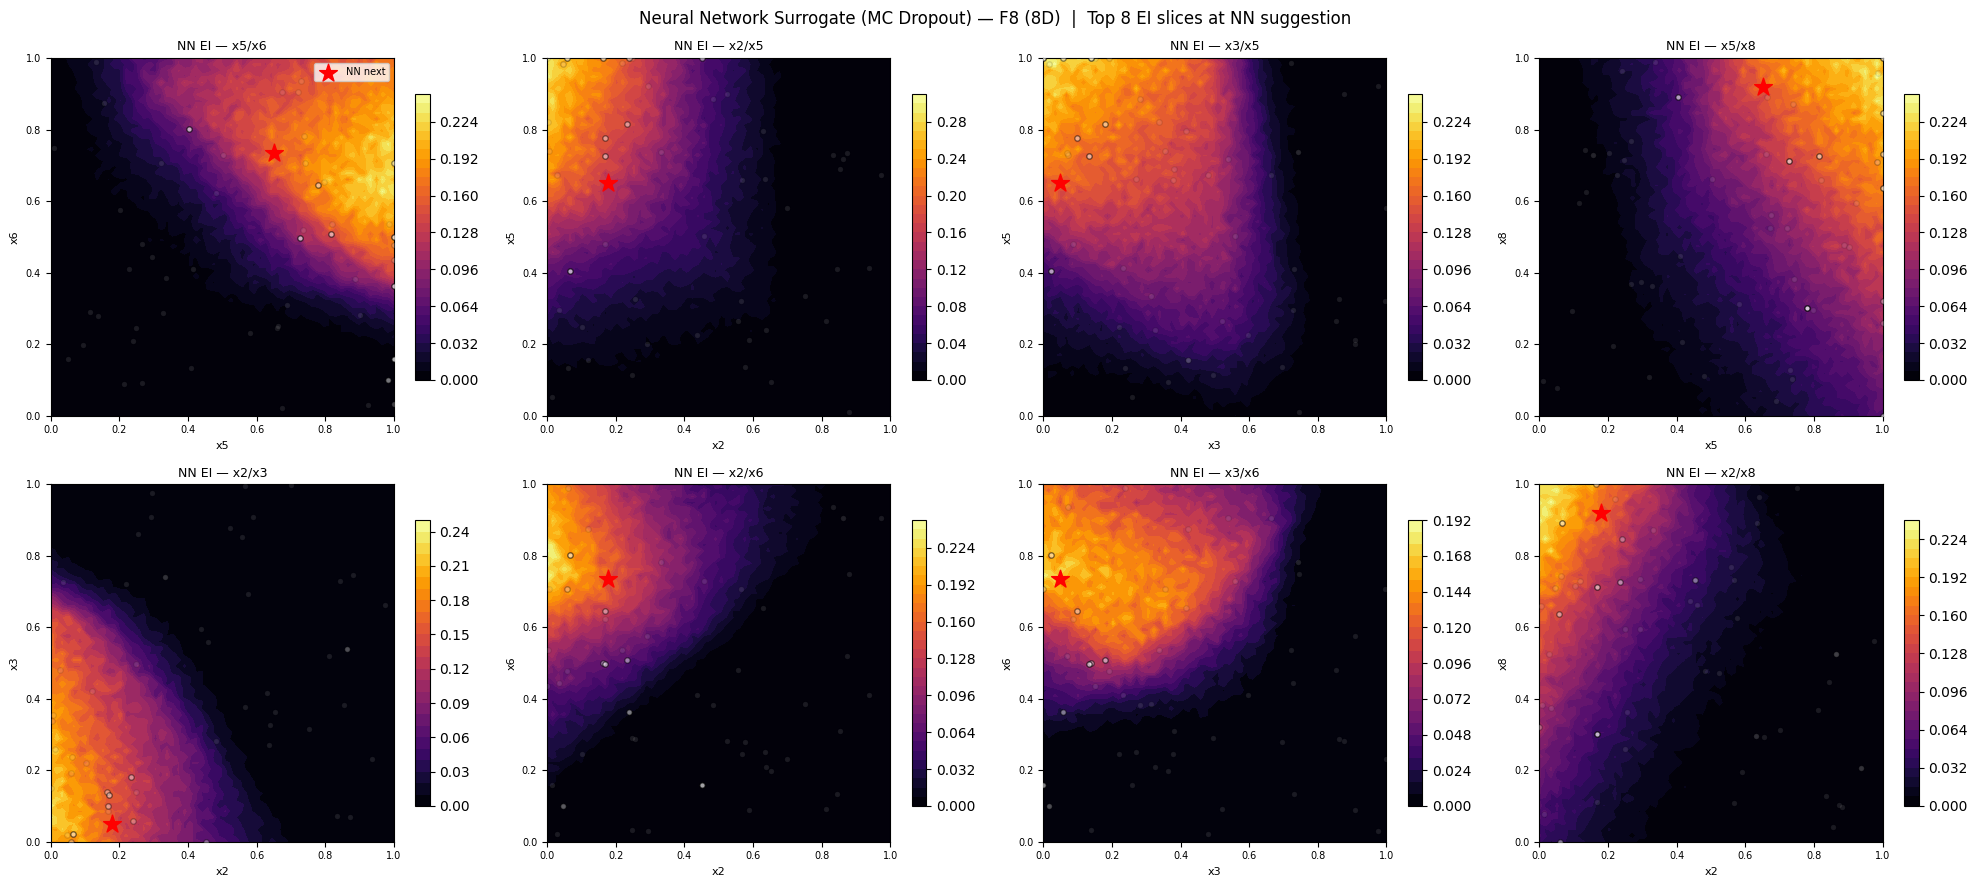

In [13]:
resolution  = 60   # matches GP slice resolution for 8D
n_top       = N_TOP
dim_labels  = [f"x{i+1}" for i in range(8)]
all_pairs   = list(combinations(range(8), 2))   # 28 pairs

grid_1d = np.linspace(0, 1, resolution)
G1, G2  = np.meshgrid(grid_1d, grid_1d)
flat1, flat2 = G1.ravel(), G2.ravel()

# ── Rank all 28 pairs by NN EI variance across the slice ─────────────────────
pair_var = []
for d0, d1 in all_pairs:
    X_grid        = np.tile(best_x_nn, (resolution * resolution, 1))
    X_grid[:, d0] = flat1
    X_grid[:, d1] = flat2
    ei_vals = expected_improvement_nn(
        X_grid, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn, n_mc=50
    )
    pair_var.append(ei_vals.var())

ranked_pairs = [p for _, p in sorted(zip(pair_var, all_pairs), key=lambda x: x[0], reverse=True)]
top_pairs    = ranked_pairs[:n_top]

print(f"\n  Top {n_top} most informative NN dimension pairs (ranked by EI variance):")
for rank, (d0, d1) in enumerate(top_pairs, 1):
    print(f"    {rank:>2}. {dim_labels[d0]}-{dim_labels[d1]}")

# ── Plot top-8 pairs in a 2×4 grid ───────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes_flat  = axes.ravel()
fig.suptitle(
    f"Neural Network Surrogate (MC Dropout) — F8 (8D)  |  Top {n_top} EI slices at NN suggestion",
    fontsize=12
)

for ax, (d0, d1) in zip(axes_flat, top_pairs):
    fixed_dims = [d for d in range(8) if d not in (d0, d1)]

    X_grid        = np.tile(best_x_nn, (resolution * resolution, 1))
    X_grid[:, d0] = flat1
    X_grid[:, d1] = flat2

    ei_vals = expected_improvement_nn(
        X_grid, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn, n_mc=200
    ).reshape(resolution, resolution)

    im = ax.contourf(G1, G2, ei_vals, levels=30, cmap="inferno")
    fig.colorbar(im, ax=ax, shrink=0.8)

    dist   = np.mean([np.abs(X_obs[:, fd] - best_x_nn[fd]) for fd in fixed_dims], axis=0)
    alphas = np.clip(1.0 - dist / 0.3, 0.1, 1.0)
    for xi_o, yi_o, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_o, yi_o, c="white", edgecolors="black",
                   s=15, alpha=float(a), zorder=5)

    ax.scatter(best_x_nn[d0], best_x_nn[d1], c="red", marker="*",
               s=180, zorder=6, label="NN next")
    ax.set_title(f"NN EI — {dim_labels[d0]}/{dim_labels[d1]}", fontsize=9)
    ax.set_xlabel(dim_labels[d0], fontsize=8)
    ax.set_ylabel(dim_labels[d1], fontsize=8)
    ax.tick_params(labelsize=7)

axes_flat[0].legend(loc="upper right", fontsize=7)
plt.tight_layout()
plt.savefig("nn_surrogate_f8.png", dpi=150)
plt.show()

## 14. Compare all three models: GP vs SVM vs NN

We compare the **EI score** and **suggested next point** from each surrogate:

| Model | Surrogate type | Uncertainty source |
|---|---|---|
| **GP** | Matérn 5/2 kernel | Bayesian posterior (exact) |
| **SVM** | RBF classifier | P(high region) — filters candidates |
| **NN** | MC-Dropout MLP | 200 stochastic forward passes |

A bar chart visualises the EI values directly, and pairwise distances quantify agreement between the three suggestions. In 8D, disagreement is common early on — the three surrogates often identify different uncertain regions as promising.

Model                                                                                         Suggested x           EI
------------------------------------------------------------------------------------------------------------------------
GP (unconstrained)       [0.013779, 0.045834, 0.151199, 0.183697, 0.702664, 0.499679, 0.145978, 0.205788]     0.000000
SVM-constrained           [0.057917, 0.08159, 0.123439, 0.118729, 0.812278, 0.504814, 0.081656, 0.641662]     0.000000
NN (MC Dropout)          [0.023667, 0.178363, 0.049903, 0.036356, 0.650978, 0.734788, 0.006369, 0.918652]     0.151756

GP  ↔ SVM distance : 0.4630
GP  ↔ NN  distance : 0.7970
SVM ↔ NN  distance : 0.4290

❗ Strong disagreement — models see different promising regions; trust the GP.


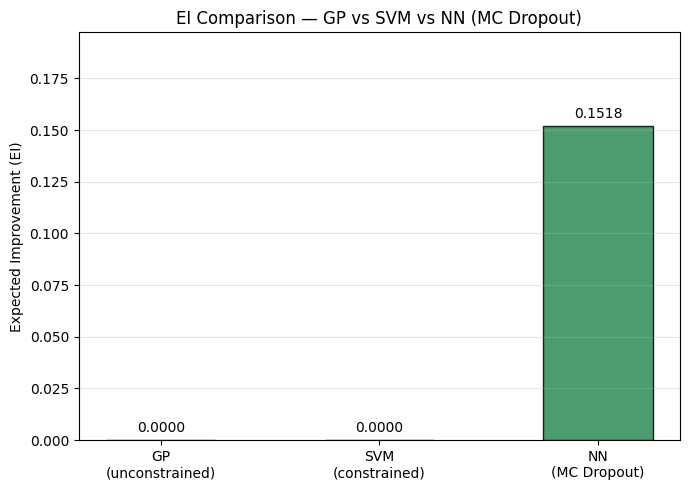

In [14]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Model':<24} {'Suggested x':>80}   {'EI':>10}")
print("-" * 120)
print(f"{'GP (unconstrained)':<24} {str(np.round(x_next, 6).tolist()):>80}   {score:>10.6f}")
print(f"{'SVM-constrained':<24} {str(np.round(best_x_svm, 6).tolist()):>80}   {best_score_svm:>10.6f}")
print(f"{'NN (MC Dropout)':<24} {str(np.round(best_x_nn, 6).tolist()):>80}   {best_score_nn:>10.6f}")

# ── Pairwise distances ────────────────────────────────────────────────────────
dist_gp_svm = np.linalg.norm(x_next - best_x_svm)
dist_gp_nn  = np.linalg.norm(x_next - best_x_nn)
dist_svm_nn = np.linalg.norm(best_x_svm - best_x_nn)

print(f"\nGP  ↔ SVM distance : {dist_gp_svm:.4f}")
print(f"GP  ↔ NN  distance : {dist_gp_nn:.4f}")
print(f"SVM ↔ NN  distance : {dist_svm_nn:.4f}")

# ── Consensus check ───────────────────────────────────────────────────────────
suggestions = [x_next, best_x_svm, best_x_nn]
centroid    = np.mean(suggestions, axis=0)
max_dev     = max(np.linalg.norm(s - centroid) for s in suggestions)

if max_dev < 0.05:
    print("\n✅ All three models agree — very high confidence in this region.")
elif max_dev < 0.15:
    print("\n⚠️  Mild disagreement — GP posterior is most principled; prefer GP suggestion.")
else:
    print("\n❗ Strong disagreement — models see different promising regions; trust the GP.")

# ── Bar chart: EI scores across the three surrogates ─────────────────────────
labels_bar    = ["GP\n(unconstrained)", "SVM\n(constrained)", "NN\n(MC Dropout)"]
ei_scores_bar = [score, best_score_svm, best_score_nn]
colors_bar    = ["steelblue", "tomato", "seagreen"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels_bar, ei_scores_bar, color=colors_bar,
              edgecolor="black", alpha=0.85, width=0.5)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)
ax.set_ylabel("Expected Improvement (EI)")
ax.set_title("EI Comparison — GP vs SVM vs NN (MC Dropout)")
ax.set_ylim(0, max(ei_scores_bar) * 1.3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ei_comparison_three_models_f8.png", dpi=150)
plt.show()

## 15. Hyperparameter Sensitivity — ξ (xi) Exploration (Module 18)

Module 18 identifies **ξ (xi)** as the key hyperparameter of the EI acquisition function controlling the exploration–exploitation trade-off. Rather than relying solely on the adaptive decay schedule, this section applies a **coarse grid search** over ξ — the simplest tuning strategy from Mini-lesson 18.5.

By scanning ξ ∈ {0.001 … 0.5} with the GP already fitted on all 8D observations, we can:
- Confirm the adaptive ξ is in a sensible range for the current dataset
- See how sensitive the suggested query is to this hyperparameter
- Decide whether to override the schedule if the function appears nearly converged (small ξ) or still widely uncertain (large ξ)

In [15]:
# ── ξ (xi) grid search — treating xi as a hyperparameter to tune ──────────────────
print('GP suggestion sensitivity to xi (exploration-exploitation hyperparameter):')
print(f"{'xi':>8}  {'EI score':>12}  Suggested x (CAPSTONE format)")
print('-' * 85)

xi_grid    = [0.001, 0.01, 0.05, 0.1, 0.5]
xi_current = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)

for xi_test in xi_grid:
    sampler_s  = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 888)
    X_c_s      = sampler_s.random(8_192)          # 2^13 quick scan
    scores_s   = expected_improvement(X_c_s, gp, y_obs.max(), xi=xi_test)
    starts_s   = X_c_s[np.argsort(scores_s)[-5:]]
    obj_s      = lambda x, xi=xi_test: -expected_improvement(x, gp, y_obs.max(), xi=xi).item()
    bx_s, bs_s = None, -np.inf
    for x0 in starts_s:
        r = minimize(obj_s, x0=x0, bounds=[(0, 1)] * n_dim, method='L-BFGS-B')
        if -r.fun > bs_s: bs_s = -r.fun; bx_s = r.x
    capstone_s = '-'.join(f'{v:.6f}' for v in bx_s)
    marker     = '  <- adaptive (current)' if abs(xi_test - xi_current) < 0.02 else ''
    print(f'  {xi_test:>6.3f}  {bs_s:>12.6f}  {capstone_s}{marker}')

print(f'\nAdaptive xi at iteration {N_ITER}: {xi_current:.5f}  '
      f'(xi_init={XI_INIT}, decay={XI_DECAY}^{N_ITER})')

GP suggestion sensitivity to xi (exploration-exploitation hyperparameter):
      xi      EI score  Suggested x (CAPSTONE format)
-------------------------------------------------------------------------------------
   0.001      0.000000  0.106098-0.021266-0.093906-0.211888-0.531961-0.401253-0.156140-0.102921  <- adaptive (current)
   0.010      0.000000  0.106098-0.021266-0.093906-0.211888-0.531961-0.401253-0.156140-0.102921  <- adaptive (current)
   0.050      0.000000  0.270792-0.012360-0.126107-0.039040-0.098050-0.605206-0.166914-0.298996
   0.100      0.000000  0.270792-0.012360-0.126107-0.039040-0.098050-0.605206-0.166914-0.298996
   0.500      0.000000  0.077310-0.487620-0.000817-0.850675-0.701848-0.063697-0.105883-0.370942

Adaptive xi at iteration 12: 0.01422  (xi_init=0.1, decay=0.85^12)


## 16. GP Kernel Diagnostics (Module 18)

The GP kernel hyperparameters are fitted by maximising the log-marginal-likelihood. Inspecting them connects to Module 18's insight that **length scales act as feature importance scores**:

- **Small length scale** → function changes quickly along that axis → high sensitivity → important dimension
- **Large length scale** → function is nearly flat along that axis → low sensitivity → potentially irrelevant

This mirrors Module 18's note that random search works well when only a few hyperparameters heavily influence performance — the same may be true of our 8D function's input dimensions. A large length-scale disparity is a signal to focus future queries on the most sensitive dimensions.

Fitted GP kernel hyperparameters (F8, 8D):
  Amplitude  s2   : 1190.8841
  Noise level     : 1.00e-10

Per-dimension length scales:
  x1:   13.4021  XXXXXXXXXXXXXXXXX
  x2:   18.3582  XXXXXXXXXXXXXXXXXX
  x3:   11.1163  XXXXXXXXXXXXXXXXX
  x4:   18.6409  XXXXXXXXXXXXXXXXXX
  x5:   25.6993  XXXXXXXXXXXXXXXXXXX
  x6:   18.5085  XXXXXXXXXXXXXXXXXX
  x7:   13.6440  XXXXXXXXXXXXXXXXX
  x8: 1000000.0000  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

Most  sensitive dim : x3 (ls=11.1163)
Least sensitive dim : x8 (ls=1000000.0000)

[!] Length scale ratio 89958x -- function may be effectively lower-dimensional. Focus future queries around x3.


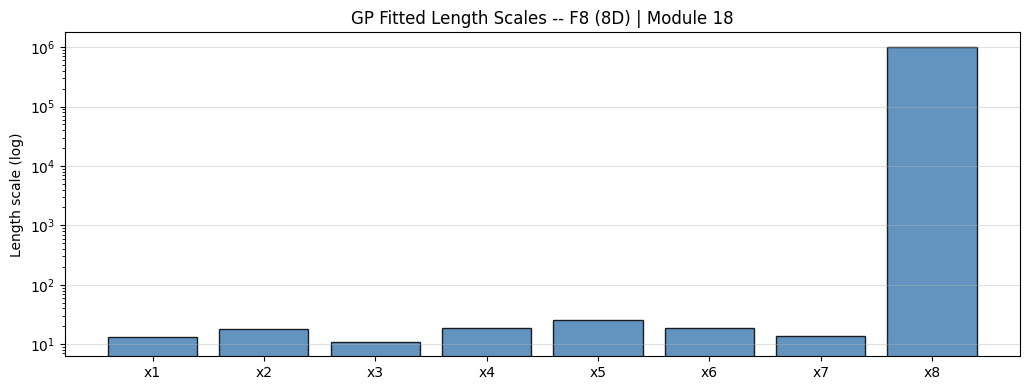

In [16]:
# ── GP fitted kernel hyperparameters ─────────────────────────────────────────────
fitted_ls = gp.kernel_.k1.k2.length_scale
noise_lv  = gp.kernel_.k2.noise_level
amplitude = gp.kernel_.k1.k1.constant_value
ls_arr    = np.array(fitted_ls)
dim_lbls  = [f'x{i+1}' for i in range(n_dim)]

print(f'Fitted GP kernel hyperparameters (F8, {n_dim}D):')
print(f'  Amplitude  s2   : {amplitude:.4f}')
print(f'  Noise level     : {noise_lv:.2e}')
print('\nPer-dimension length scales:')
for lbl, ls in zip(dim_lbls, ls_arr):
    bar = 'X' * max(1, min(int(np.log10(ls + 1e-8) * 5 + 12), 35))
    print(f'  {lbl}: {ls:9.4f}  {bar}')

if n_dim >= 3:
    idx_min, idx_max = ls_arr.argmin(), ls_arr.argmax()
    ratio = ls_arr[idx_max] / (ls_arr[idx_min] + 1e-8)
    print(f'\nMost  sensitive dim : {dim_lbls[idx_min]} (ls={ls_arr[idx_min]:.4f})')
    print(f'Least sensitive dim : {dim_lbls[idx_max]} (ls={ls_arr[idx_max]:.4f})')
    if ratio > 10:
        print(f'\n[!] Length scale ratio {ratio:.0f}x -- function may be effectively '
              f'lower-dimensional. Focus future queries around {dim_lbls[idx_min]}.')
    else:
        print(f'\n[OK] Length scale ratio {ratio:.1f}x -- all dimensions contribute similarly.')

fig, ax = plt.subplots(figsize=(max(6, n_dim * 1.3), 4))
ax.bar(dim_lbls, ls_arr, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_yscale('log')
ax.set_ylabel('Length scale (log)')
ax.set_title(f'GP Fitted Length Scales -- F8 ({n_dim}D) | Module 18')
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('length_scales_module18_f8.png', dpi=150)
plt.show()

## 17. Convergence Plot

After running multiple iterations with real evaluations, this cell plots the **best observed value over time**.

In 8D, expect a slower and noisier convergence curve than in lower-dimensional functions — the optimizer may explore widely for many iterations before reliably improving the best value. Key things to watch:

- **Flat stretches**: if the best value does not improve for 5+ consecutive iterations, consider temporarily increasing `xi` or switching to `ACQ = "ucb"` to force more exploration
- **Consistent top pairs**: if the same 2-3 dimensions consistently rank highest in the slice visualisation, the function is likely low-effective-dimensional. The GP length scale plot in Section 9 provides a complementary view

Uncomment and run after completing multiple BO iterations.

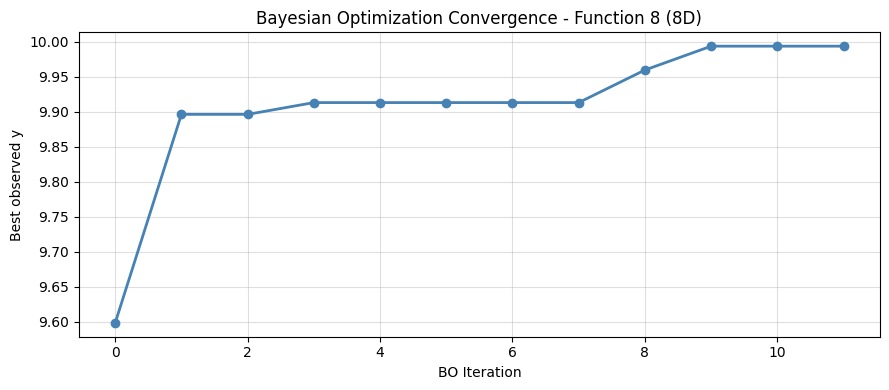

In [17]:
plt.figure(figsize=(9, 4))
plt.plot(range(len(history_best)), history_best, marker="o", linewidth=2, color="steelblue")
plt.xlabel("BO Iteration")
plt.ylabel("Best observed y")
plt.title("Bayesian Optimization Convergence - Function 8 (8D)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("convergence_f8.png", dpi=150)
plt.show()

## 9. Bonus — GP Length Scale Inspection

In high dimensions, the fitted GP kernel's **per-dimension length scales** are a valuable diagnostic unique to F8 among all notebooks in this series. A very large length scale for a dimension means the GP thinks the function varies slowly along that axis — which can indicate the dimension is relatively unimportant for finding the optimum.

If some dimensions consistently show length scales 10-100x larger than others across multiple iterations, the function may be **effectively lower-dimensional** than 8D. This insight could justify focusing future evaluations on the important dimensions, or switching to a lower-dimensional surrogate.

Uncomment and run after the BO loop has fitted the GP.

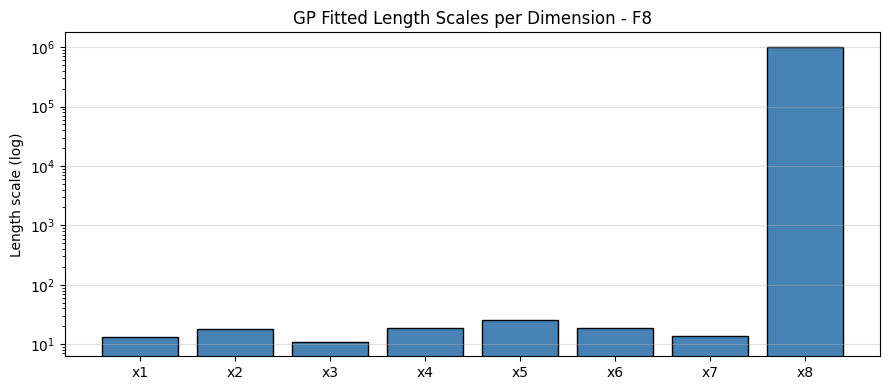

Fitted length scales:
  x1: 13.4021
  x2: 18.3582
  x3: 11.1163
  x4: 18.6409
  x5: 25.6993
  x6: 18.5085
  x7: 13.6440
  x8: 1000000.0000


In [18]:
# Extract and plot fitted per-dimension length scales
# Run this cell after the BO loop has executed at least one iteration.
#
fitted_ls  = gp.kernel_.k1.k2.length_scale
dim_labels = [f"x{i+1}" for i in range(n_dim)]
#
plt.figure(figsize=(9, 4))
plt.bar(dim_labels, fitted_ls, color="steelblue", edgecolor="black")
plt.yscale("log")
plt.ylabel("Length scale (log)")
plt.title("GP Fitted Length Scales per Dimension - F8")
plt.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("length_scales_f8.png", dpi=150)
plt.show()
#
print("Fitted length scales:")
for label, ls in zip(dim_labels, fitted_ls):
    print(f"  {label}: {ls:.4f}")